# DATASET LOADING




In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

In [69]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Path to dataset files: /kaggle/input/brazilian-ecommerce


In [70]:
# Download latest version
path = kagglehub.dataset_download("olistbr/marketing-funnel-olist")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'marketing-funnel-olist' dataset.
Path to dataset files: /kaggle/input/marketing-funnel-olist


In [71]:
base = "/kaggle/input/brazilian-ecommerce"
funnel_base = "/kaggle/input/marketing-funnel-olist"

#base
customers = pd.read_csv(f"{base}/olist_customers_dataset.csv")
orders = pd.read_csv(f"{base}/olist_orders_dataset.csv")
order_items = pd.read_csv(f"{base}/olist_order_items_dataset.csv")
products = pd.read_csv(f"{base}/olist_products_dataset.csv")
payments = pd.read_csv(f"{base}/olist_order_payments_dataset.csv")
reviews = pd.read_csv(f"{base}/olist_order_reviews_dataset.csv")
sellers = pd.read_csv(f"{base}/olist_sellers_dataset.csv")
geolocation = pd.read_csv(f"{base}/olist_geolocation_dataset.csv")
cat_transl = pd.read_csv(f"{base}/product_category_name_translation.csv")

#funnel_base
closed_deals = pd.read_csv(f"{funnel_base}/olist_closed_deals_dataset.csv")
mql_leads = pd.read_csv(f"{funnel_base}/olist_marketing_qualified_leads_dataset.csv")


#EDA

##CUSTOMERS


(99441, 5)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



Null:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

unique:
customer_id                 99441
customer_unique_id          96096
customer_zip_code_prefix    14994
customer_city                4119
customer_state                 27
dtype: int64


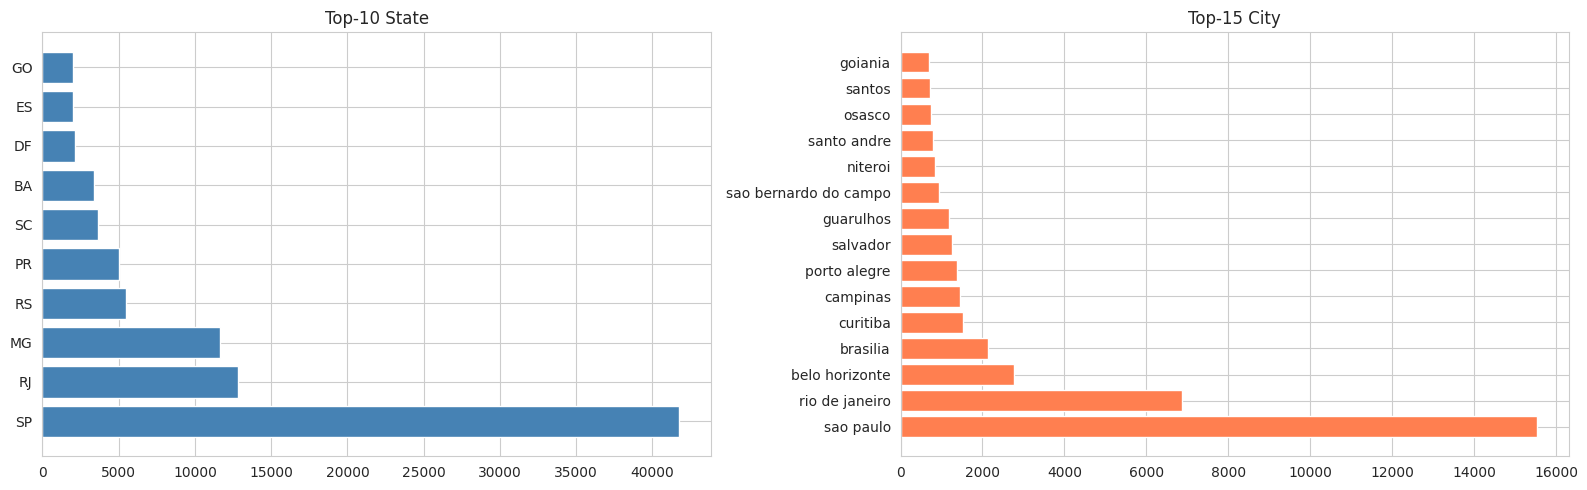

In [72]:
print(f"{customers.shape}")
display(customers.head())
print("\nNull:")
print(customers.isnull().sum())
print("\nunique:")
print(customers.nunique())

fig, axes = plt.subplots(1,2, figsize=(16,5))
top_states = customers['customer_state'].value_counts().nlargest(10)
axes[0].barh(top_states.index, top_states.values, color='steelblue')
axes[0].set_title('Top‑10 State')
top_cities = customers['customer_city'].value_counts().nlargest(15)
axes[1].barh(top_cities.index, top_cities.values, color='coral')
axes[1].set_title('Top-15 City')
plt.tight_layout()
plt.show()


##ORDERS

(99441, 8)

Null:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

СStatus:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


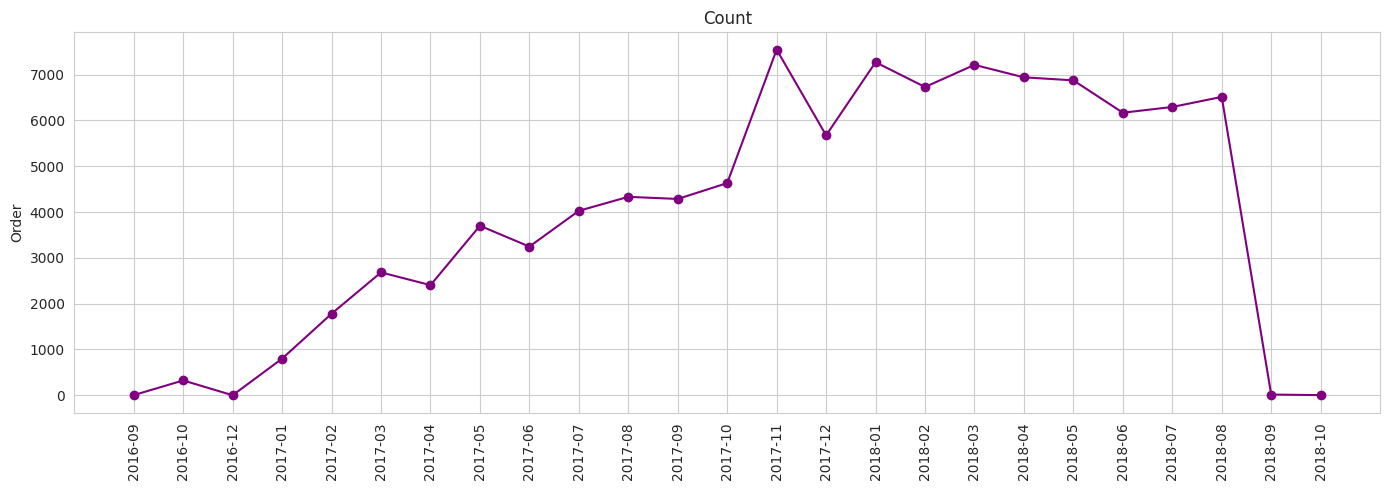

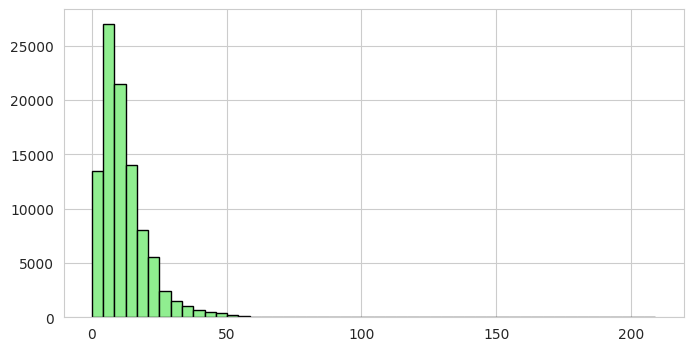

In [73]:
print(f"{orders.shape}")
print("\nNull:")
print(orders.isnull().sum())
print("\nСStatus:")
print(orders['order_status'].value_counts())

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M').astype(str)
month_counts = orders['month'].value_counts().sort_index()
plt.figure(figsize=(14,5))
plt.plot(month_counts.index, month_counts.values, color='purple', marker='o')
plt.xticks(rotation=90)
plt.title('Count')
plt.ylabel('Order')
plt.tight_layout()
plt.show()

delivered = orders[orders['order_status']=='delivered'].copy()
delivered['delivery_days'] = (delivered['order_delivered_customer_date'] - delivered['order_purchase_timestamp']).dt.days
plt.figure(figsize=(8,4))
plt.hist(delivered['delivery_days'], bins=50, color='lightgreen', edgecolor='black')
plt.show()

In [74]:
orders_del = orders[orders['order_status'] == 'delivered'].copy()

print("\nПропуски в доставленных заказах:")
print(orders_del.isnull().sum())


Пропуски в доставленных заказах:
order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
month                             0
dtype: int64


##ORDER_ITEMS + PAYMENTS + REVIEWS

ORDER_ITEMS
(112650, 7)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14



Null:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

price:
count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

freight_value:
count    112650.000000
mean         19.990320
std          15.806405
min           0.000000
25%          13.080000
50%          16.260000
75%          21.150000
max         409.680000
Name: freight_value, dtype: float64


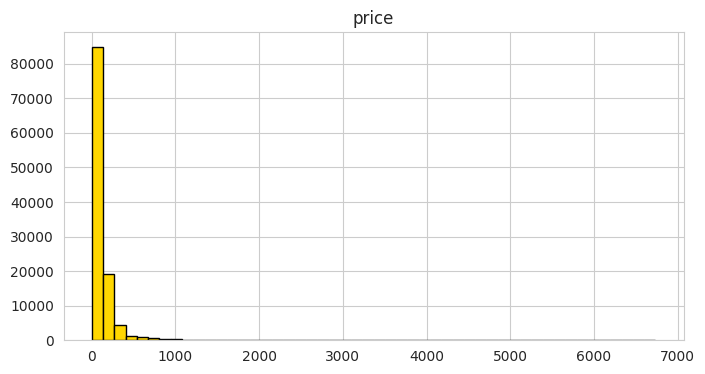

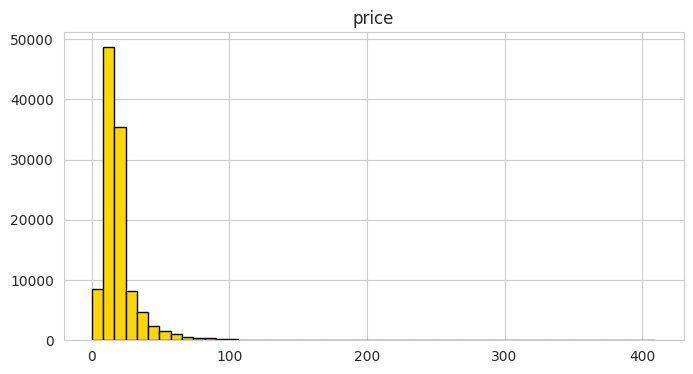

In [75]:
print("ORDER_ITEMS")
print(f"{order_items.shape}")
display(order_items.head())
print("\nNull:")
print(order_items.isnull().sum())
print("\nprice:")
print(order_items['price'].describe())
print("\nfreight_value:")
print(order_items['freight_value'].describe())

plt.figure(figsize=(8,4))
plt.hist(order_items['price'], bins=50, color='gold', edgecolor='black')
plt.title('price')
plt.show()

plt.figure(figsize=(8,4))
plt.hist(order_items['freight_value'], bins=50, color='gold', edgecolor='black')
plt.title('price')
plt.show()

In [76]:
# PAYMENTS
print("PAYMENTS")
print(f"{payments.shape}")
display(payments.head())
print("\nNull:")
print(payments.isnull().sum())
print("\npayment_type:")
print(payments['payment_type'].value_counts())
print("\npayment_value:")
print(payments['payment_value'].describe())

PAYMENTS
(103886, 5)


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45



Null:
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

payment_type:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

payment_value:
count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64


REVIEWS
(99224, 7)


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53



Null:
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

review_score:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


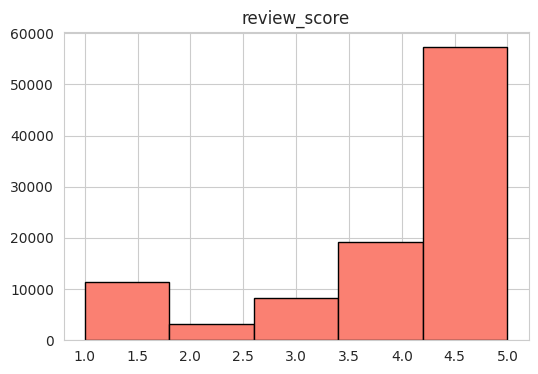

In [77]:
# REVIEWS
print("REVIEWS")
print(f"{reviews.shape}")
display(reviews.head())
print("\nNull:")
print(reviews.isnull().sum())
print("\nreview_score:")
print(reviews['review_score'].value_counts().sort_index())

plt.figure(figsize=(6,4))
reviews['review_score'].hist(bins=5, color='salmon', edgecolor='black')
plt.title('review_score')
plt.show()

 ## PRODUCTS

PRODUCTS
(32951, 9)


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0



Null:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64
       product_name_lenght  product_description_lenght  product_photos_qty  \
count         32341.000000                32341.000000        32341.000000   
mean             48.476949                  771.495285            2.188986   
std              10.245741                  635.115225            1.736766   
min               5.000000                    4.000000            1.000000   
25%              42.000000                  339.000000            1.000000   
50%              51.000000                  595.000000            1.000000   
75%              57.000000                  972.000000            3.000000   
max              76.000000                 3992.00

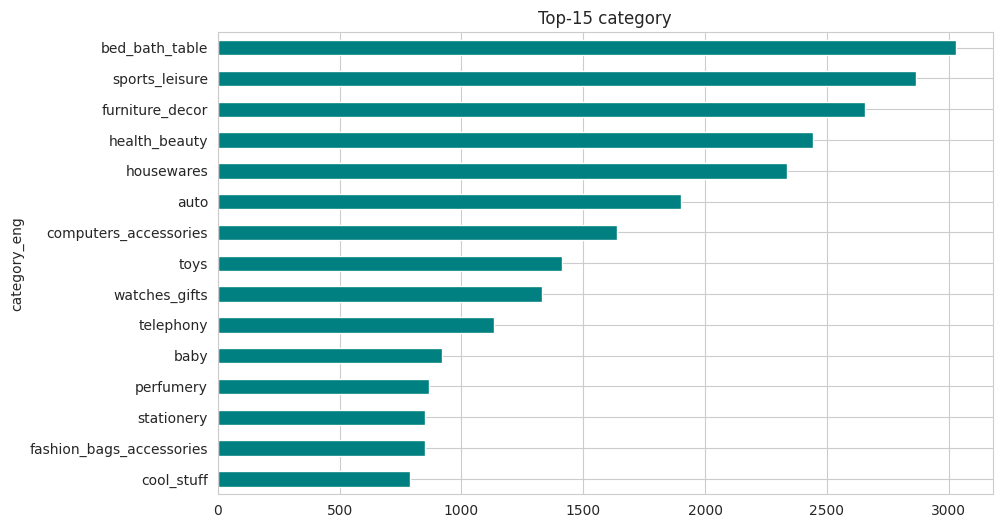

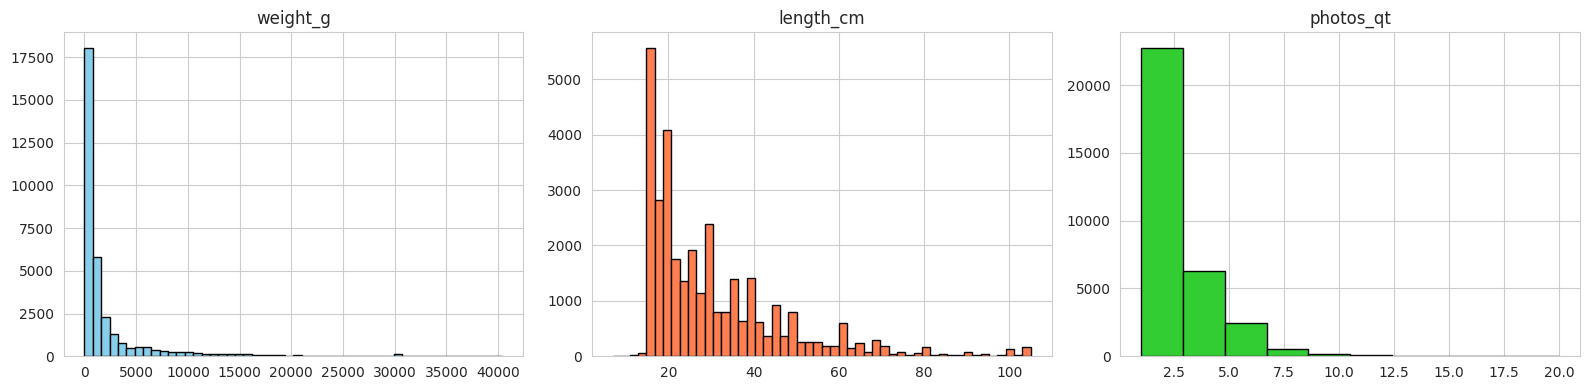

In [78]:
print("PRODUCTS")
print(f"{products.shape}")
display(products.head())
print("\nNull:")
print(products.isnull().sum())
print(products.describe())

products_with_cat = products.merge(cat_transl, on='product_category_name', how='left')
products_with_cat['category_eng'] = products_with_cat['product_category_name_english'].fillna('other')
top_cats = products_with_cat['category_eng'].value_counts().nlargest(15)

plt.figure(figsize=(10,6))
top_cats.plot(kind='barh', color='teal')
plt.title('Top-15 category')
plt.gca().invert_yaxis()
plt.show()

fig, axes = plt.subplots(1,3, figsize=(16,4))
axes[0].hist(products['product_weight_g'].dropna(), bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('weight_g')
axes[1].hist(products['product_length_cm'].dropna(), bins=50, color='coral', edgecolor='black')
axes[1].set_title('length_cm')
axes[2].hist(products['product_photos_qty'].dropna(), bins=10, color='limegreen', edgecolor='black')
axes[2].set_title('photos_qt')
plt.tight_layout()
plt.show()

In [79]:
missing_cat = products[products['product_category_name'].isnull() & products['product_name_lenght'].isnull() & products['product_description_lenght'].isnull() & products['product_photos_qty'].isnull()]
print(f"missing_cat: {missing_cat.shape[0]}")
display(missing_cat.head())

missing_weight = products[products['product_weight_g'].isnull() & products['product_length_cm'].isnull() & products['product_height_cm'].isnull() & products['product_width_cm'].isnull() & products['product_category_name'].notnull()]
print(f"\nmissing_weight: {missing_weight.shape[0]}")
display(missing_weight.head())

missing_cat: 610


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0



missing_weight: 1


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN


## SELLERS и GEOLOCATION

SELLERS
(3095, 4)


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP



Null:
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

Top-10 State:
seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
Name: count, dtype: int64


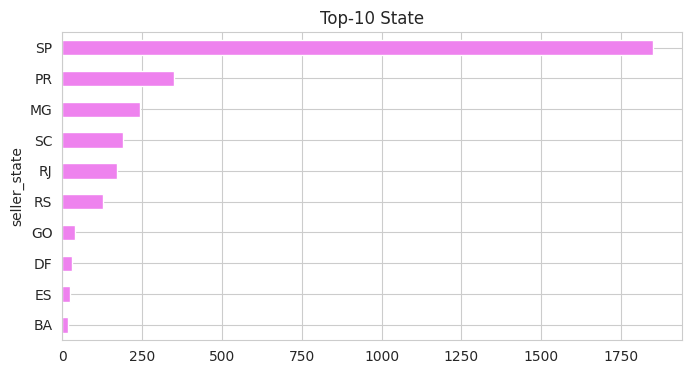

In [80]:
print("SELLERS")
print(f"{sellers.shape}")
display(sellers.head())
print("\nNull:")
print(sellers.isnull().sum())
print("\nTop-10 State:")
print(sellers['seller_state'].value_counts().nlargest(10))

plt.figure(figsize=(8,4))
sellers['seller_state'].value_counts().nlargest(10).plot(kind='barh', color='violet')
plt.title('Top-10 State')
plt.gca().invert_yaxis()
plt.show()

In [81]:
#GEOLOCATION
print("GEOLOCATION")
print(f"{geolocation.shape}")
display(geolocation.head())
print("\nNull:")
print(geolocation.isnull().sum())
print("\ngeolocation_zip_code_prefix:", geolocation['geolocation_zip_code_prefix'].nunique())

GEOLOCATION
(1000163, 5)


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP



Null:
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

geolocation_zip_code_prefix: 19015


## MARKETING FUNNEL

CLOSED_DEALS
(842, 14)


,mql_id,seller_id,sdr_id,sr_id,won_date,business_segment,lead_type,lead_behaviour_profile,has_company,has_gtin,average_stock,business_type,declared_product_catalog_size,declared_monthly_revenue
0,5420aad7fec3549a85876ba1c529bd84,2c43fb513632d29b3b58df74816f1b06,a8387c01a09e99ce014107505b92388c,4ef15afb4b2723d8f3d81e51ec7afefe,2018-02-26 19:58:54,pet,online_medium,cat,NaN,NaN,NaN,reseller,NaN,0.0
1,a555fb36b9368110ede0f043dfc3b9a0,bbb7d7893a450660432ea6652310ebb7,09285259593c61296eef10c734121d5b,d3d1e91a157ea7f90548eef82f1955e3,2018-05-08 20:17:59,car_accessories,industry,eagle,NaN,NaN,NaN,reseller,NaN,0.0
2,327174d3648a2d047e8940d7d15204ca,612170e34b97004b3ba37eae81836b4c,b90f87164b5f8c2cfa5c8572834dbe3f,6565aa9ce3178a5caf6171827af3a9ba,2018-06-05 17:27:23,home_appliances,online_big,cat,NaN,NaN,NaN,reseller,NaN,0.0
3,f5fee8f7da74f4887f5bcae2bafb6dd6,21e1781e36faf92725dde4730a88ca0f,56bf83c4bb35763a51c2baab501b4c67,d3d1e91a157ea7f90548eef82f1955e3,2018-01-17 13:51:03,food_drink,online_small,NaN,NaN,NaN,NaN,reseller,NaN,0.0
4,ffe640179b554e295c167a2f6be528e0,ed8cb7b190ceb6067227478e48cf8dde,4b339f9567d060bcea4f5136b9f5949e,d3d1e91a157ea7f90548eef82f1955e3,2018-07-03 20:17:45,home_appliances,industry,wolf,NaN,NaN,NaN,manufacturer,NaN,0.0



Null:
mql_id                             0
seller_id                          0
sdr_id                             0
sr_id                              0
won_date                           0
business_segment                   1
lead_type                          6
lead_behaviour_profile           177
has_company                      779
has_gtin                         778
average_stock                    776
business_type                     10
declared_product_catalog_size    773
declared_monthly_revenue           0
dtype: int64

business_segment:
business_segment
home_decor                         105
health_beauty                       93
car_accessories                     77
household_utilities                 71
construction_tools_house_garden     69
audio_video_electronics             64
computers                           34
pet                                 30
food_supplement                     28
food_drink                          26
sports_leisure                      

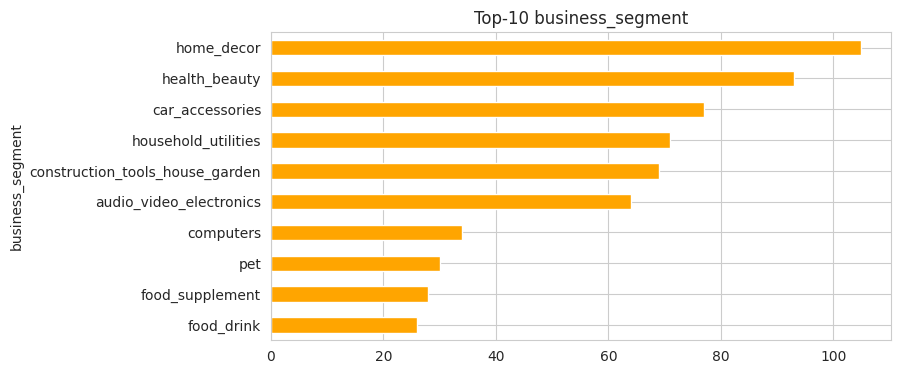

In [82]:
print("CLOSED_DEALS")
print(f"{closed_deals.shape}")
display(closed_deals.head())
print("\nNull:")
print(closed_deals.isnull().sum())
print("\nbusiness_segment:")
print(closed_deals['business_segment'].value_counts())
print("\nlead_type:")
print(closed_deals['lead_type'].value_counts())
print("\ndeclared_monthly_revenue:")
print(closed_deals['declared_monthly_revenue'].describe())

plt.figure(figsize=(8,4))
closed_deals['business_segment'].value_counts().nlargest(10).plot(kind='barh', color='orange')
plt.title('Top-10 business_segment')
plt.gca().invert_yaxis()
plt.show()



In [83]:
print("MQL_LEADS")
print(f"{mql_leads.shape}")
display(mql_leads.head())
print("\nNull:")
print(mql_leads.isnull().sum())
print("\norigin:")
print(mql_leads['origin'].value_counts())

MQL_LEADS
(8000, 4)


,mql_id,first_contact_date,landing_page_id,origin
0,dac32acd4db4c29c230538b72f8dd87d,2018-02-01,88740e65d5d6b056e0cda098e1ea6313,social
1,8c18d1de7f67e60dbd64e3c07d7e9d5d,2017-10-20,007f9098284a86ee80ddeb25d53e0af8,paid_search
2,b4bc852d233dfefc5131f593b538befa,2018-03-22,a7982125ff7aa3b2054c6e44f9d28522,organic_search
3,6be030b81c75970747525b843c1ef4f8,2018-01-22,d45d558f0daeecf3cccdffe3c59684aa,email
4,5420aad7fec3549a85876ba1c529bd84,2018-02-21,b48ec5f3b04e9068441002a19df93c6c,organic_search



Null:
mql_id                 0
first_contact_date     0
landing_page_id        0
origin                60
dtype: int64

origin:
origin
organic_search       2296
paid_search          1586
social               1350
unknown              1099
direct_traffic        499
email                 493
referral              284
other                 150
display               118
other_publicities      65
Name: count, dtype: int64


## EDA Summary

**CUSTOMER:**

1. There are 99,441 unique records (customer_id), but only 96,096 unique customers (customer_unique_id). If this field is required, focus primarily on customer_unique_id.
2. No missing values detected.
3. The number of cities is too high for analysis; use customer_state instead (27 unique values, which can be grouped).



**ORDERS:**


1. 99,441 unique records.
2. Missing values are present.
3. For clustering, it is better to use delivered items (delivered — 96,478 records), which constitute the vast majority and have almost no missing values. Furthermore, it is precisely successful and delivered transactions that we want to study.


**ORDER_ITEMS + PAYMENTS + REVIEWS:**


1. Use product price and shipping price.
2.  payment_type is an important indicator. It can be grouped to highlight those who prefer to pay upon receipt of the goods. Advance payment: credit_card, debit_card, voucher. Post-payment: boleto.
3. Review text has a significant number of missing values and cannot be used. Product review score is necessary.

**PRODUCTS:**

1. 32,951 records — this is our target for segmentation.
2. 610 missing values in product types and categories. It is necessary to drop them for the model to work correctly.
3. Product categories will need to be merged into larger subgroups.
4. Use English product category names.

**SELLERS и GEOLOCATION**



1. Seller regions are available.
2. The remaining columns will not be considered in the model.

**Marketing Funnel:**


1. 842 successfully acquired sellers.
2. Business segments: 33 unique values — can be grouped.
3. Lead types (lead_type): 8 unique values.


**Далее формируем итоговый датасет,анализируем его для построения модели.**

# CREATING A UNIFIED PRODUCT TABLE

Based on the analysis conducted, we will form the primary table structure:

1. Basic product characteristics (PRODUCTS):
* product_id - key
* category_group - grouped categories
* product_name_lenght, product_description_lenght,   product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm — product characteristics
* Records with Null values are removed from the list as errors

2.   Sales statistics:
* total_sold — how many times the product was purchased
* total_revenue
* avg_unit_price а
* unique_customers  
* n_sellers  

3. Product quality:
* avg_review_score    
* avg_delivery_days    
* sales_per_month  

4. Географические признаки:
* seller_region_top1  
* customer_region_top1  

## Создание датасета

In [84]:
category_group_map = {
    # 1. Electronics (компактная техника, гаджеты)
    'audio': 'Electronics', 'cine_photo': 'Electronics', 'computers': 'Electronics',
    'computers_accessories': 'Electronics', 'consoles_games': 'Electronics',
    'dvds_blu_ray': 'Electronics', 'electronics': 'Electronics', 'fixed_telephony': 'Electronics',
    'tablets_printing_image': 'Electronics', 'telephony': 'Electronics',
    'small_appliances': 'Electronics', 'small_appliances_home_oven_and_coffee': 'Electronics',
    'musical_instruments': 'Electronics', 'air_conditioning': 'Electronics',

    # 2. Home & Decor (мебель, декор, посуда)
    'bed_bath_table': 'Home & Decor', 'furniture_bedroom': 'Home & Decor',
    'furniture_decor': 'Home & Decor', 'furniture_living_room': 'Home & Decor',
    'furniture_mattress_and_upholstery': 'Home & Decor', 'home_comfort_2': 'Home & Decor',
    'home_confort': 'Home & Decor', 'housewares': 'Home & Decor',
    'office_furniture': 'Home & Decor', 'kitchen_dining_laundry_garden_furniture': 'Home & Decor',
    'la_cuisine': 'Home & Decor',

    # 3. Construction & Tools (инструменты, стройка)
    'construction_tools_construction': 'Construction & Tools',
    'construction_tools_lights': 'Construction & Tools',
    'construction_tools_safety': 'Construction & Tools',
    'costruction_tools_garden': 'Construction & Tools',
    'costruction_tools_tools': 'Construction & Tools',
    'home_construction': 'Construction & Tools',
    'garden_tools': 'Construction & Tools',

    # 4. Fashion (одежда, обувь)
    'fashio_female_clothing': 'Fashion', 'fashion_male_clothing': 'Fashion',
    'fashion_childrens_clothes': 'Fashion', 'fashion_shoes': 'Fashion',
    'fashion_sport': 'Fashion', 'fashion_underwear_beach': 'Fashion',

    # 5. Accessories & Luggage (аксессуары, сумки, украшения)
    'fashion_bags_accessories': 'Accessories & Luggage',
    'luggage_accessories': 'Accessories & Luggage',
    'watches_gifts': 'Accessories & Luggage',

    # 6. Beauty & Health (красота, гигиена)
    'health_beauty': 'Beauty & Health', 'perfumery': 'Beauty & Health',
    'diapers_and_hygiene': 'Beauty & Health',

    # 7. Sports & Leisure (спорт, игры, хобби)
    'sports_leisure': 'Sports & Leisure', 'toys': 'Sports & Leisure',
    'art': 'Sports & Leisure', 'arts_and_craftmanship': 'Sports & Leisure',
    'music': 'Sports & Leisure', 'cds_dvds_musicals': 'Sports & Leisure',
    'cool_stuff': 'Sports & Leisure',

    # 8. Books & Stationery (книги, канцелярия)
    'books_general_interest': 'Books & Stationery', 'books_imported': 'Books & Stationery',
    'books_technical': 'Books & Stationery', 'stationery': 'Books & Stationery',

    # 9. Food & Drinks (продукты, напитки)
    'drinks': 'Food & Drinks', 'food': 'Food & Drinks', 'food_drink': 'Food & Drinks',

    # 10. Garden, B2B & Others (сад, промышленность, прочее)
    'agro_industry_and_commerce': 'Garden, B2B & Others',
    'flowers': 'Garden, B2B & Others',
    'industry_commerce_and_business': 'Garden, B2B & Others',
    'market_place': 'Garden, B2B & Others',
    'pet_shop': 'Garden, B2B & Others',
    'security_and_services': 'Garden, B2B & Others',
    'signaling_and_security': 'Garden, B2B & Others',
    'baby': 'Garden, B2B & Others',
    'christmas_supplies': 'Garden, B2B & Others',
    'party_supplies': 'Garden, B2B & Others',
}

region_map = {
    'AC': 'Norte', 'AM': 'Norte', 'AP': 'Norte', 'PA': 'Norte', 'RO': 'Norte', 'RR': 'Norte', 'TO': 'Norte',
    'AL': 'Nordeste', 'BA': 'Nordeste', 'CE': 'Nordeste', 'MA': 'Nordeste',
    'PB': 'Nordeste', 'PE': 'Nordeste', 'PI': 'Nordeste', 'RN': 'Nordeste', 'SE': 'Nordeste',
    'DF': 'Centro-Oeste', 'GO': 'Centro-Oeste', 'MS': 'Centro-Oeste', 'MT': 'Centro-Oeste',
    'ES': 'Sudeste', 'MG': 'Sudeste', 'RJ': 'Sudeste', 'SP': 'Sudeste',
    'PR': 'Sul', 'RS': 'Sul', 'SC': 'Sul'
}

In [85]:
# Удаляем товары без категории (610 шт.)
products_clean = products.dropna(subset=['product_category_name']).copy()
# Присоединяем английские названия
products_clean = products_clean.merge(cat_transl, on='product_category_name', how='left')
# Макро-категория
products_clean['category_group'] = products_clean['product_category_name_english'].map(category_group_map).fillna('Other')
print(f"Товаров после очистки: {products_clean.shape[0]}")

Товаров после очистки: 32341


In [86]:
orders_del = orders[orders['order_status'] == 'delivered'].copy()
orders_del['order_purchase_timestamp'] = pd.to_datetime(orders_del['order_purchase_timestamp'])
max_date = orders_del['order_purchase_timestamp'].max()

# Присоединяем customer_unique_id
orders_del = orders_del.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left')

trans = orders_del[['order_id', 'customer_id', 'customer_unique_id', 'order_purchase_timestamp']] \
    .merge(order_items[['order_id', 'product_id', 'seller_id', 'price', 'freight_value']], on='order_id') \
    .merge(payments.groupby('order_id')['payment_value'].sum().reset_index(), on='order_id', how='left') \
    .merge(products_clean[['product_id', 'category_group']], on='product_id', how='inner')
print(f"Транзакций: {trans.shape[0]}, товаров: {trans['product_id'].nunique()}")

Транзакций: 108660, товаров: 31632


In [87]:
# Статистики продаж
prod_stats = trans.groupby('product_id').agg(
    total_sold        = ('order_id', 'count'),
    total_revenue     = ('payment_value', 'sum'),
    unique_customers  = ('customer_unique_id', 'nunique'),
    n_sellers         = ('seller_id', 'nunique')
).reset_index()

# Качество
# Средняя оценка
prod_rev = trans[['product_id','order_id']].merge(reviews[['order_id','review_score']], on='order_id')
avg_score = prod_rev.groupby('product_id')['review_score'].mean().reset_index(name='avg_review_score')

# Среднее время доставки
delivery = orders_del[['order_id','order_purchase_timestamp','order_delivered_customer_date']]
prod_del = trans[['product_id','order_id']].merge(delivery, on='order_id')
prod_del['delivery_days'] = (prod_del['order_delivered_customer_date'] - prod_del['order_purchase_timestamp']).dt.days
avg_deliv = prod_del.groupby('product_id')['delivery_days'].mean().reset_index(name='avg_delivery_days')

# Продаж в месяц
first_order = trans.groupby('product_id')['order_purchase_timestamp'].min().reset_index(name='first_order_date')
sales_per_month = prod_stats.merge(first_order, on='product_id')
sales_per_month['months_since_first'] = ((max_date - sales_per_month['first_order_date']).dt.days / 30).clip(lower=1)
sales_per_month['sales_per_month'] = sales_per_month['total_sold'] / sales_per_month['months_since_first']

# География
# Продавцы
sellers['seller_region'] = sellers['seller_state'].map(region_map).fillna('unknown')
trans_seller = trans.merge(sellers[['seller_id', 'seller_region']], on='seller_id', how='left')
seller_geo = trans_seller.groupby('product_id')['seller_region'].agg(
    seller_region_top1 = lambda x: x.value_counts().index[0] if len(x) > 0 else 'unknown'
).reset_index()

# Покупатели
customers['customer_region'] = customers['customer_state'].map(region_map).fillna('unknown')
trans_cust = trans.merge(customers[['customer_unique_id', 'customer_region']], on='customer_unique_id', how='left')
customer_geo = trans_cust.groupby('product_id')['customer_region'].agg(
    customer_region_top1 = lambda x: x.value_counts().index[0] if len(x) > 0 else 'unknown'
).reset_index()

# Средняя цена за единицу
avg_price = (prod_stats['total_revenue'] / prod_stats['total_sold']).rename('avg_unit_price')
avg_price = pd.concat([prod_stats['product_id'], avg_price], axis=1)

In [88]:
base_cols = ['product_id', 'category_group',
             'product_name_lenght', 'product_description_lenght', 'product_photos_qty',
             'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

prod_feat = products_clean[base_cols] \
    .merge(prod_stats, on='product_id', how='left') \
    .merge(avg_score, on='product_id', how='left') \
    .merge(avg_deliv, on='product_id', how='left') \
    .merge(sales_per_month[['product_id', 'sales_per_month']], on='product_id', how='left') \
    .merge(seller_geo[['product_id', 'seller_region_top1']], on='product_id', how='left') \
    .merge(customer_geo[['product_id', 'customer_region_top1']], on='product_id', how='left') \
    .merge(avg_price, on='product_id', how='left')

# Оставляем только продававшиеся товары и без пропусков
prod_feat_clean = prod_feat[prod_feat['total_sold'] > 0].copy()
prod_feat_clean.dropna(inplace=True)

print(f"Финальная таблица: {prod_feat_clean.shape}")
print("Колонки:", prod_feat_clean.columns.tolist())

Финальная таблица: (31489, 19)
Колонки: ['product_id', 'category_group', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'total_sold', 'total_revenue', 'unique_customers', 'n_sellers', 'avg_review_score', 'avg_delivery_days', 'sales_per_month', 'seller_region_top1', 'customer_region_top1', 'avg_unit_price']


In [89]:
print("Нулей в product_weight_g до замены:", (prod_feat_clean['product_weight_g'] == 0).sum())
prod_feat_clean['product_weight_g'] = prod_feat_clean['product_weight_g'].replace(0, np.nan)
prod_feat_clean['product_weight_g'] = prod_feat_clean.groupby('category_group')['product_weight_g'].transform(
    lambda x: x.fillna(x.median())
)


Нулей в product_weight_g до замены: 4


## Анализ датасета

In [90]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [91]:
print("ОПИСАТЕЛЬНАЯ СТАТИСТИКА ЧИСЛОВЫХ ПРИЗНАКОВ")
display(prod_feat_clean.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(2))

ОПИСАТЕЛЬНАЯ СТАТИСТИКА ЧИСЛОВЫХ ПРИЗНАКОВ


,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,total_sold,total_revenue,unique_customers,n_sellers,avg_review_score,avg_delivery_days,sales_per_month,avg_unit_price
count,31489.00,31489.00,31489.00,31489.00,31489.00,31489.00,31489.00,31489.00,31489.00,31489.00,31489.00,31489.00,31489.00,31489.00,31489.00
mean,48.54,771.70,2.19,2268.57,30.82,16.89,23.18,3.44,617.55,3.12,1.05,4.12,11.65,0.53,193.51
std,10.20,635.07,1.74,4259.21,16.89,13.59,12.04,10.64,2164.52,9.40,0.26,1.15,8.28,1.12,289.07
min,5.00,4.00,1.00,2.00,7.00,2.00,6.00,1.00,9.59,1.00,1.00,1.00,1.00,0.04,9.59
10%,33.00,207.00,1.00,175.00,16.00,4.00,11.00,1.00,51.59,1.00,1.00,2.40,4.00,0.08,41.99
25%,42.00,339.00,1.00,300.00,18.00,8.00,15.00,1.00,93.19,1.00,1.00,3.80,7.00,0.12,65.86
50%,51.00,595.00,1.00,700.00,25.00,13.00,20.00,1.00,199.90,1.00,1.00,4.50,10.00,0.25,116.82
75%,57.00,974.00,3.00,1900.00,38.00,20.00,30.00,3.00,481.77,2.00,1.00,5.00,14.33,0.61,208.55
90%,59.00,1575.20,5.00,6300.00,53.00,33.00,40.00,6.00,1188.33,6.00,1.00,5.00,20.00,1.00,382.18
max,76.00,3992.00,20.00,40425.00,105.00,105.00,118.00,520.00,109312.64,456.00,8.00,5.00,195.00,70.26,13664.08


РАСПРЕДЕЛЕНИЕ МАКРО-КАТЕГОРИЙ
category_group
Home & Decor             8540
Sports & Leisure         5035
Electronics              4433
Beauty & Health          3257
Accessories & Luggage    2465
Other                    2307
Garden, B2B & Others     2023
Construction & Tools     1625
Books & Stationery       1189
Fashion                   357
Food & Drinks             258
Name: count, dtype: int64


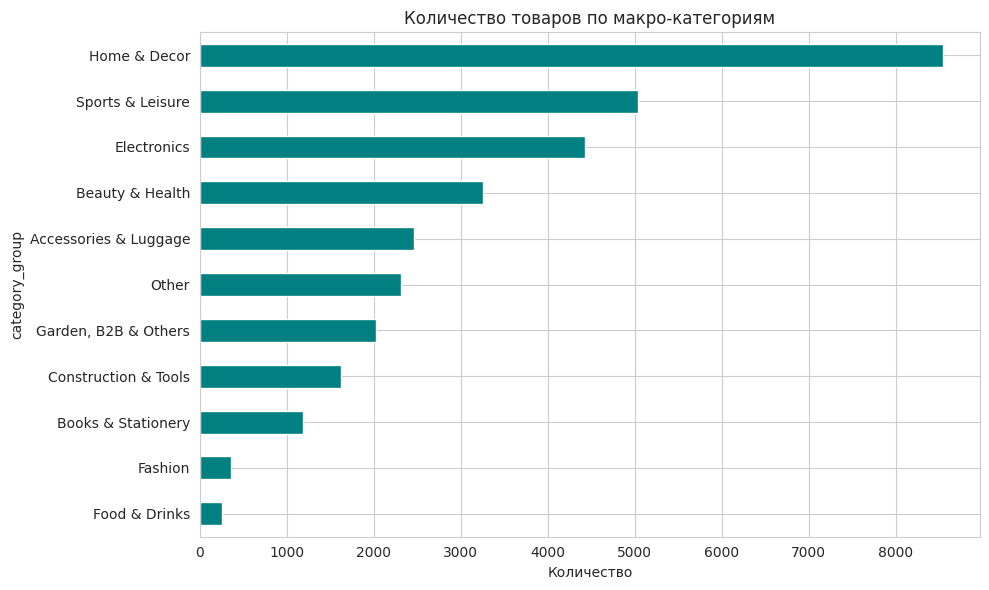

In [92]:
print("РАСПРЕДЕЛЕНИЕ МАКРО-КАТЕГОРИЙ")

cat_counts = prod_feat_clean['category_group'].value_counts()
print(cat_counts)

plt.figure(figsize=(10, 6))
cat_counts.plot(kind='barh', color='teal')
plt.title('Количество товаров по макро-категориям')
plt.xlabel('Количество')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



РАСПРЕДЕЛЕНИЕ РЕГИОНОВ ПРОДАВЦОВ (seller_region_top1)
seller_region_top1
Sudeste         81.574518
Sul             15.354568
Centro-Oeste     2.061037
Nordeste         0.943187
Norte            0.066690
Name: proportion, dtype: float64

РАСПРЕДЕЛЕНИЕ РЕГИОНОВ ПОКУПАТЕЛЕЙ (customer_region_top1)
customer_region_top1
Sudeste         73.574899
Sul             12.429737
Nordeste         7.567722
Centro-Oeste     4.839785
Norte            1.587856
Name: proportion, dtype: float64


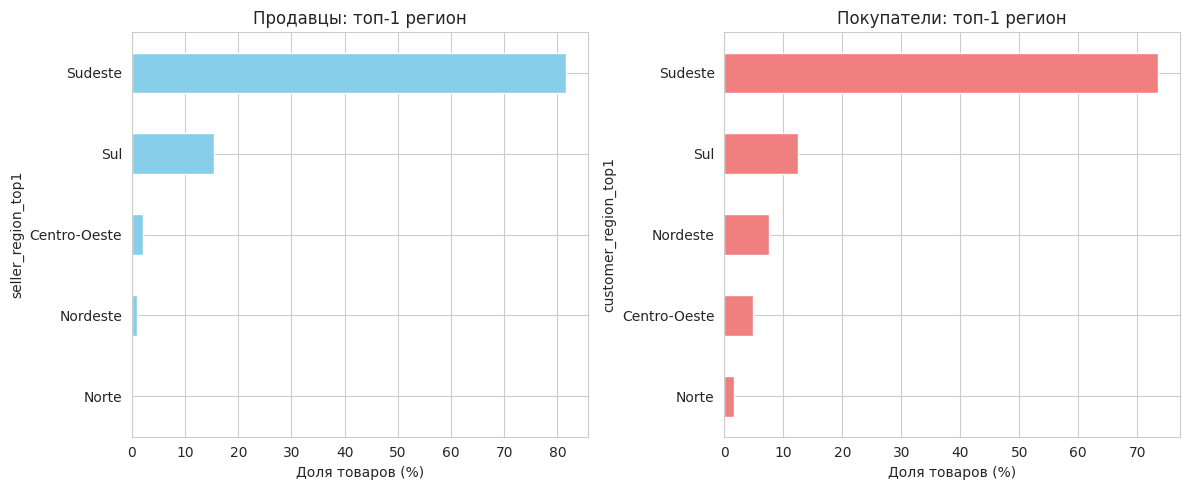

In [93]:
print("РАСПРЕДЕЛЕНИЕ РЕГИОНОВ ПРОДАВЦОВ (seller_region_top1)")
seller_region_counts = prod_feat_clean['seller_region_top1'].value_counts(normalize=True) * 100
print(seller_region_counts)

print("\nРАСПРЕДЕЛЕНИЕ РЕГИОНОВ ПОКУПАТЕЛЕЙ (customer_region_top1)")
customer_region_counts = prod_feat_clean['customer_region_top1'].value_counts(normalize=True) * 100
print(customer_region_counts)

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
seller_region_counts.plot(kind='barh', ax=ax1, color='skyblue')
ax1.set_title('Продавцы: топ-1 регион')
ax1.set_xlabel('Доля товаров (%)')
ax1.invert_yaxis()

customer_region_counts.plot(kind='barh', ax=ax2, color='lightcoral')
ax2.set_title('Покупатели: топ-1 регион')
ax2.set_xlabel('Доля товаров (%)')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

In [94]:
print("ПРОВЕРКА ПРОПУСКОВ И НУЛЕЙ")
print("Пропусков (NaN) в каждой колонке:")
print(prod_feat_clean.isnull().sum())
print(f"\nСуммарное количество пропусков: {prod_feat_clean.isnull().sum().sum()}")

num_cols = prod_feat_clean.select_dtypes(include='number').columns
print("\nКоличество нулей в числовых колонках:")
zero_counts = (prod_feat_clean[num_cols] == 0).sum()
print(zero_counts[zero_counts > 0] if zero_counts.sum() > 0 else "Нулей нет")


ПРОВЕРКА ПРОПУСКОВ И НУЛЕЙ
Пропусков (NaN) в каждой колонке:
product_id                    0
category_group                0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
total_sold                    0
total_revenue                 0
unique_customers              0
n_sellers                     0
avg_review_score              0
avg_delivery_days             0
sales_per_month               0
seller_region_top1            0
customer_region_top1          0
avg_unit_price                0
dtype: int64

Суммарное количество пропусков: 0

Количество нулей в числовых колонках:
Нулей нет


ГИСТОГРАММЫ ОСНОВНЫХ ПРИЗНАКОВ


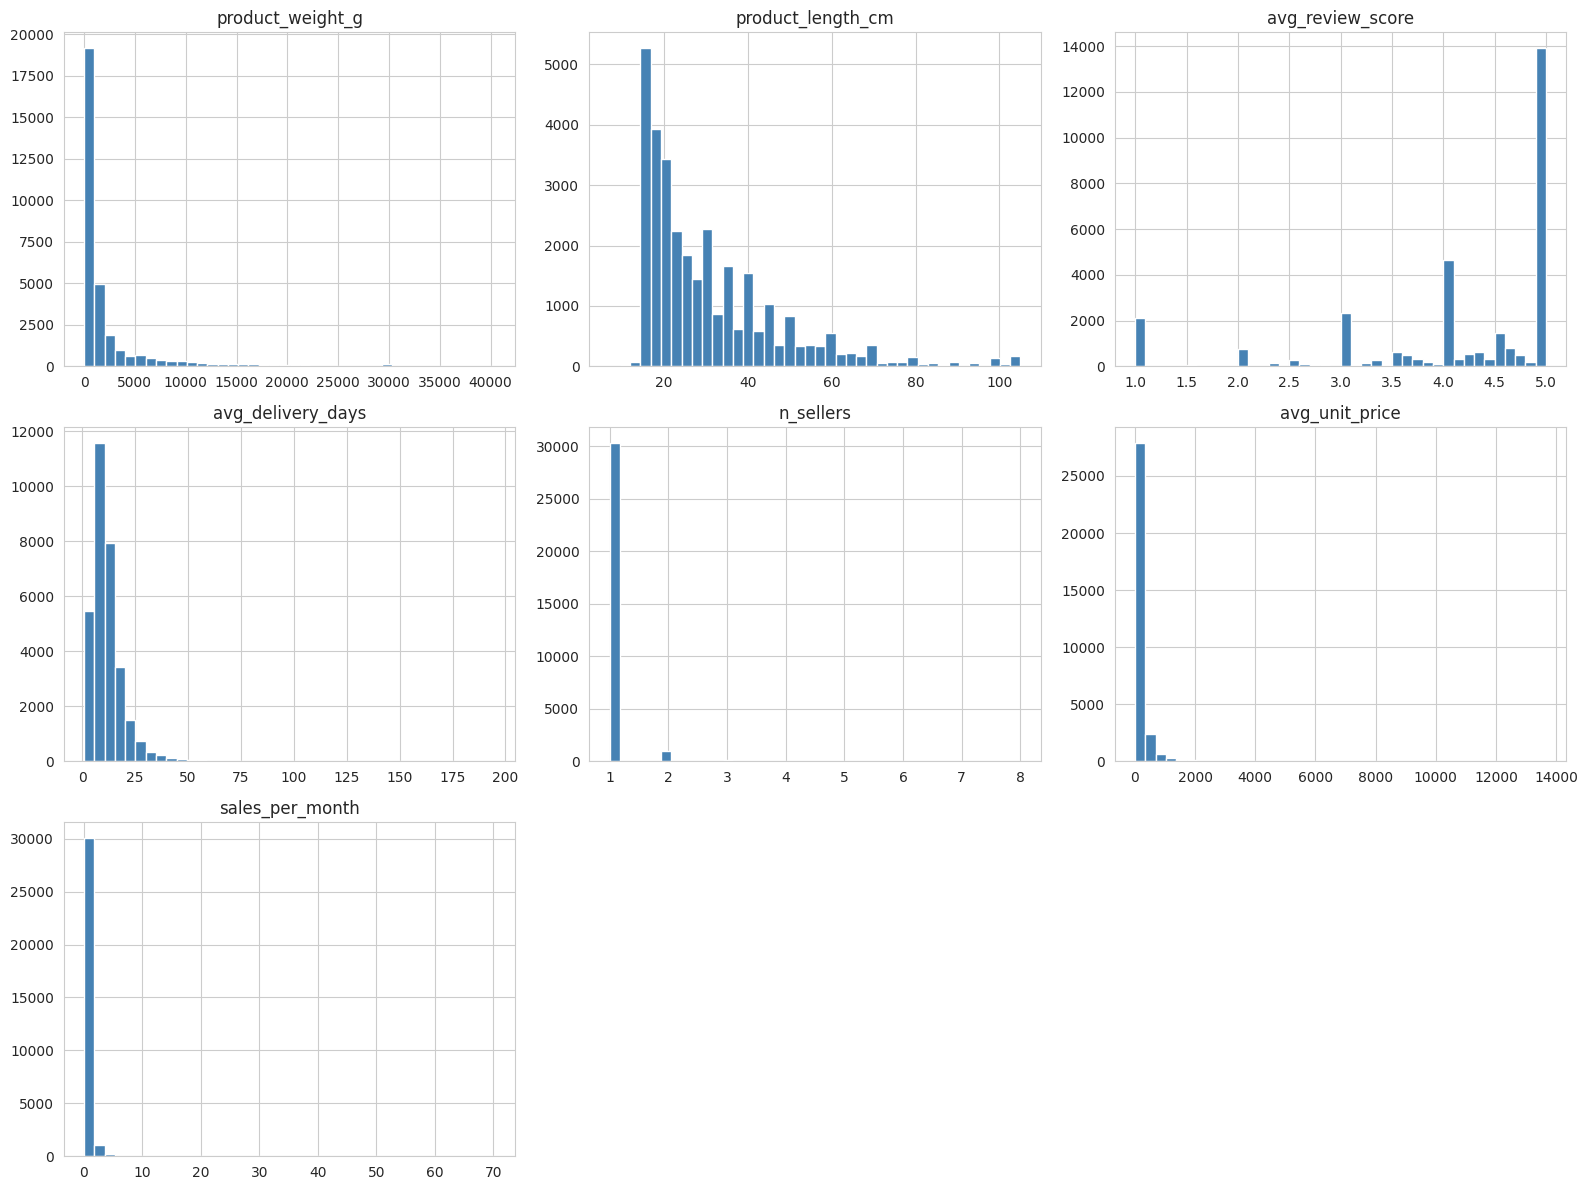

In [95]:
print("ГИСТОГРАММЫ ОСНОВНЫХ ПРИЗНАКОВ")
main_features = ['product_weight_g', 'product_length_cm', 'avg_review_score',
                 'avg_delivery_days', 'n_sellers', 'avg_unit_price', 'sales_per_month']
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(main_features):
    if col in prod_feat_clean.columns:
        axes[i].hist(prod_feat_clean[col], bins=40, color='steelblue', edgecolor='white')
        axes[i].set_title(col)
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

# Recommendation Models

## General Data Preparation and Hold-Out Split

In [96]:
from collections import defaultdict

# Keep only unique products for each customer across transactions
trans_unique = trans.drop_duplicates(subset=['customer_unique_id', 'product_id'])

# Filter users who have 2 or more distinct purchases remaining
user_counts = trans_unique.groupby('customer_unique_id').size()
valid_users = user_counts[user_counts >= 2].index
trans_filtered = trans_unique[trans_unique['customer_unique_id'].isin(valid_users)]

# Set up base indices for the marketplace catalog
prod_feat_clean_reset = prod_feat_clean.reset_index(drop=True)
cat_col = 'category_group'
pid_to_idx = pd.Series(prod_feat_clean_reset.index, index=prod_feat_clean_reset['product_id']).to_dict()
idx_to_pid = {v: k for k, v in pid_to_idx.items()}

# Collect user history consisting of unique products only
full_user_history = trans_filtered.groupby('customer_unique_id')['product_id'].apply(list).to_dict()

# Perform hold-out split into training and validation sets
train_user_history = {}
val_user_data = {}
np.random.seed(42)

for uid, items in full_user_history.items():
    valid_items = [p for p in items if p in pid_to_idx]
    if len(valid_items) < 2:
        continue

    # Products are guaranteed to be unique here, so we can safely pick a random one
    hidden_item = np.random.choice(valid_items)
    remaining_items = [p for p in valid_items if p != hidden_item]

    if remaining_items:
        train_user_history[uid] = remaining_items
        val_user_data[uid] = {'remaining': remaining_items, 'hidden': hidden_item}

# Build inverted training indices for graph-based calculations
train_user_to_items = {uid: set(items) for uid, items in train_user_history.items()}
train_item_to_users = defaultdict(set)
for uid, items in train_user_history.items():
    for item in items:
        train_item_to_users[item].add(uid)

print(f"Preparation complete. Unique users for validation: {len(val_user_data)}")

Preparation complete. Unique users for validation: 5214


## Item‑Based Collaborative Filtering +  Swing
Classic Item-Based CF builds a co-purchase matrix for items and finds those that are most frequently bought together for each item.

Swing is an enhanced version of Item-Based CF (developed by Alibaba). It accounts not just for the fact of a co-purchase, but for the "swing" effect — if two users bought not only items A and B but also many other identical items, their contribution to the similarity of the A–B pair is downweighted.

In [97]:
def calculate_swing_matrix_fixed(user_to_items, item_to_users, alpha=1.0, top_n=50):

    swing_scores = defaultdict(dict)

    # Iterate through each item and check who bought it
    for item_i, users_i in item_to_users.items():
        item_scores = defaultdict(float)
        candidate_items = set()

        # Collect all items that these same users also purchased
        for u in users_i:
            candidate_items.update(user_to_items[u])
        candidate_items.discard(item_i) # Do not compare the item with itself

        # Calculate similarity score with all identified candidates
        for item_j in candidate_items:
            users_j = item_to_users[item_j]
            common_users = list(users_i & users_j) # Intersection: users who bought both i and j

            # Swing requires at least 2 common users to capture the "swing" effect
            if len(common_users) < 2:
                continue

            total_weight = 0.0
            # Pairwise compare users who bought both items
            for i in range(len(common_users)):
                for j in range(i + 1, len(common_users)):
                    u = common_users[i]
                    v = common_users[j]

                    # Check how many OTHER common items they have purchased
                    overlap = len(user_to_items[u] & user_to_items[v])
                    # Downweight the connection if users have highly identical baskets
                    total_weight += 1.0 / (alpha + overlap)

            if total_weight > 0:
                item_scores[item_j] = total_weight

        # If similar items were found, retain only the Top-N strongest connections
        if item_scores:
            sorted_scores = sorted(item_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
            swing_scores[item_i] = dict(sorted_scores)

    return swing_scores

# Train Swing on our clean training data
swing_matrix = calculate_swing_matrix_fixed(train_user_to_items, train_item_to_users, alpha=1.0, top_n=50)

# Proceed to model validation
hit_m1, prec_m1, total_m1 = 0, 0.0, 0
k = 10 # We will recommend 10 items per user

# Validate on the hold-out set reserved in the first cell
for uid, info in val_user_data.items():
    remaining = set(info['remaining'])
    hidden = info['hidden']           # Hidden item to be predicted
    candidates = defaultdict(float)

    # Search for similar items via the Swing matrix for each item in the open history
    for item in remaining:
        if item in swing_matrix:
            for sim_item, score in swing_matrix[item].items():
                if sim_item not in remaining:  # Do not recommend items the user has already bought
                    candidates[sim_item] += score

    # Sort candidates by weight and extract the Top-10
    final_recs = [item for item, _ in sorted(candidates.items(), key=lambda x: x[1], reverse=True)[:k]]

    # Compute metrics: check if the hidden item is included in our top recommendations
    if hidden in final_recs:
        hit_m1 += 1
        prec_m1 += 1.0 / k
    total_m1 += 1

# Output final model metrics
print(f"Swing Model Metrics")
print(f"Hit Rate@10: {hit_m1 / total_m1:.4f}")
print(f"Precision@10: {prec_m1 / total_m1:.4f}\n")

example_item = None
for pid in prod_feat_clean_reset['product_id']:
    # Find an item for which Swing managed to find at least k recommendations
    if isinstance(pid, str) and pid in swing_matrix and len(swing_matrix[pid]) >= k:
        example_item = pid
        break

if not example_item and swing_matrix:
    example_item = list(swing_matrix.keys())[0]

# Display example recommendations
if example_item and example_item in pid_to_idx:
    idx_ex = pid_to_idx[example_item]
    print(f"Swing Recommendation Example")
    print(f"Source Item: {example_item}")
    print(f"Category: {prod_feat_clean_reset.loc[idx_ex, cat_col]} | Price: {prod_feat_clean_reset.loc[idx_ex, 'avg_unit_price']}\n")

    recs = list(swing_matrix[example_item].items())[:k]
    print(f"Recommended Items:")
    for rank, (rec_id, score) in enumerate(recs, 1):
        if rec_id in pid_to_idx:
            idx_rec = pid_to_idx[rec_id]
            cat = prod_feat_clean_reset.loc[idx_rec, cat_col]
            price = prod_feat_clean_reset.loc[idx_rec, 'avg_unit_price']
            print(f"{rank}. ID: {rec_id} | Score: {score:.4f} | Category: {cat} | Price: {price}")



Swing Model Metrics
Hit Rate@10: 0.0046
Precision@10: 0.0005

Swing Recommendation Example
Source Item: af0a917aec9cea3b353ece61a8825326
Category: Home & Decor | Price: 127.86631578947369

Recommended Items:
1. ID: 42a2bd596fda1baef5719cb74f73030c | Score: 0.3333 | Category: Home & Decor | Price: 177.293


##  Content‑Based Filtering:
An item embedding is a compressed vector that captures the "meaning" of a product. It implicitly encodes its category, price, customer reviews, and other attributes.The geometry of meaning: Vectors of similar items (such as two different smartphone cases or two types of coffee) lie close to each other in this space, while the vectors of a refrigerator and a children's toy are far apart.Cosine Similarity is the mathematical ruler used here. It measures the angle between two vectors. If the angle is 0° (cosine = 1), the items are identical in meaning. If the angle is 90° (cosine = 0), they have absolutely nothing in common [O1].

In [98]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import RobustScaler
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack

# Text encoding of marketplace macro-categories
vectorizer = TfidfVectorizer(max_features=100, token_pattern=r'(?u)\b\w+\b')
x_txt = vectorizer.fit_transform(prod_feat_clean_reset[cat_col].astype(str))

# Scaling content features excluding sales dynamics
num_features = [
    'product_name_lenght', 'product_description_lenght', 'product_photos_qty',
    'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm',
    'avg_review_score', 'avg_delivery_days', 'avg_unit_price'
]
num_features = [c for c in num_features if c in prod_feat_clean_reset.columns]
scaler = RobustScaler()
x_num = scaler.fit_transform(prod_feat_clean_reset[num_features])

# Encoding geographical locations of sellers and customers
geo_features = ['seller_region_top1', 'customer_region_top1']
geo_features = [c for c in geo_features if c in prod_feat_clean_reset.columns]

if geo_features:
    x_geo = pd.get_dummies(prod_feat_clean_reset[geo_features], drop_first=False).values
    x_content = hstack([x_txt, x_num, x_geo]).tocsr()
else:
    x_content = hstack([x_txt, x_num]).tocsr()

hit_m2, prec_m2, total_m2 = 0, 0.0, 0
k = 10

# Validating the accuracy of content-based search via cosine similarity
for uid, info in val_user_data.items():
    rem_indices = [pid_to_idx[p] for p in info['remaining'] if p in pid_to_idx]
    if not rem_indices or (info['hidden'] not in pid_to_idx):
        continue
    hidden_idx = pid_to_idx[info['hidden']]

    sims_matrix = cosine_similarity(x_content[rem_indices], x_content)
    sims = np.max(sims_matrix, axis=0)
    sims[rem_indices] = -1.0

    # Correctly selecting Top-K positions with guaranteed sorting by score
    top_indices = np.argsort(sims)[::-1][:k]

    if hidden_idx in top_indices:
        hit_m2 += 1
        # Find the exact rank of the hidden item for accuracy calculation
        rank = np.where(top_indices == hidden_idx)[0][0]
        prec_m2 += 1.0 / k
    total_m2 += 1

print(f"Content-Based Model Metrics")
print(f"Hit Rate@10: {hit_m2 / total_m2:.4f}")
print(f"Precision@10: {prec_m2 / total_m2:.4f}\n")

# Top-10 recommendation generation example
example_item = prod_feat_clean_reset.loc[0, 'product_id']
if example_item in pid_to_idx:
    idx_ex = pid_to_idx[example_item]
    print(f"Content-Based Recommendation Example")
    print(f"Source Item: {example_item}")
    print(f"Category: {prod_feat_clean_reset.loc[idx_ex, cat_col]} | Price: {prod_feat_clean_reset.loc[idx_ex, 'avg_unit_price']}\n")

    sims_matrix_ex = cosine_similarity(x_content[[idx_ex]], x_content)
    sims_ex = sims_matrix_ex.flatten()
    sims_ex[idx_ex] = -1.0
    top_indices_ex = np.argsort(sims_ex)[::-1][:k]

    print(f"Recommended Items:")
    for rank, idx_rec in enumerate(top_indices_ex, 1):
        rec_id = prod_feat_clean_reset.loc[idx_rec, 'product_id']
        score = sims_ex[idx_rec]
        cat = prod_feat_clean_reset.loc[idx_rec, cat_col]
        price = prod_feat_clean_reset.loc[idx_rec, 'avg_unit_price']
        print(f"{rank}. ID: {rec_id} | Score: {score:.4f} | Category: {cat} | Price: {price}")



Content-Based Model Metrics
Hit Rate@10: 0.2158
Precision@10: 0.0216

Content-Based Recommendation Example
Source Item: 1e9e8ef04dbcff4541ed26657ea517e5
Category: Beauty & Health | Price: 18.3

Recommended Items:
1. ID: eaac4fc2977aa6f917c42e6fc02d0ece | Score: 0.9805 | Category: Beauty & Health | Price: 47.6
2. ID: de4fdf07188007d3f9847a7ebe30039c | Score: 0.9794 | Category: Beauty & Health | Price: 45.27
3. ID: 24b861426de01a8adcf503251efe05f1 | Score: 0.9769 | Category: Beauty & Health | Price: 44.41
4. ID: b868a7a3ed7a16bae1b565d21102dd9a | Score: 0.9759 | Category: Beauty & Health | Price: 36.35
5. ID: 0c3497a215eb37d2e70682bfde05c93a | Score: 0.9748 | Category: Beauty & Health | Price: 28.29
6. ID: 662eb743b41155e398e7fdd5d4cf5a3a | Score: 0.9708 | Category: Beauty & Health | Price: 48.17
7. ID: 50b82b74dfaf7b1e257d85b3e58bb977 | Score: 0.9700 | Category: Beauty & Health | Price: 17.78
8. ID: 9e61f47367a7a1d6cafa44817f88f8db | Score: 0.9692 | Category: Beauty & Health | Price: 17

## Two-Stage Score Fusion Hybrid

The model combines two fundamentally different sources of product knowledge: semantic (Content-Based) and behavioral (Alibaba Swing).

In [99]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

hit_m3, prec_m3, total_m3 = 0, 0.0, 0
k = 10

# Validating the hybrid fusion of normalized content cosine similarity and Swing graph
for uid, info in val_user_data.items():
    rem_indices = [pid_to_idx[p] for p in info['remaining'] if p in pid_to_idx]
    if not rem_indices or (info['hidden'] not in pid_to_idx):
        continue
    hidden_idx = pid_to_idx[info['hidden']]

    # Calculate the base content similarity matrix using cosine distance
    sims_matrix = cosine_similarity(x_content[rem_indices], x_content)
    hybrid_sims = np.max(sims_matrix, axis=0)

    # Normalize content scores to a strict interval between 0 and 1
    sims_min, sims_max = hybrid_sims.min(), hybrid_sims.max()
    if sims_max - sims_min > 0:
        hybrid_sims = (hybrid_sims - sims_min) / (sims_max - sims_min)

    # Dynamically inject numerical weights from the Swing matrix
    for item in info['remaining']:
        if item in swing_matrix:
            for target_pid, swing_weight in swing_matrix[item].items():
                if target_pid in pid_to_idx:
                    # Apply behavioral factor from co-purchased baskets with a multiplier of 3.0
                    hybrid_sims[pid_to_idx[target_pid]] += swing_weight * 3.0

    hybrid_sims[rem_indices] = -1.0

    # Correctly selecting Top-K positions with guaranteed sorting by score
    top_indices = np.argsort(hybrid_sims)[::-1][:k]

    if hidden_idx in top_indices:
        hit_m3 += 1
        prec_m3 += 1.0 / k
    total_m3 += 1

print(f"Hybrid Model Metrics")
print(f"Hit Rate@10: {hit_m3 / total_m3:.4f}")
print(f"Precision@10: {prec_m3 / total_m3:.4f}\n")

# Extract an example item to visualize the results
if example_item in pid_to_idx:
    idx_ex = pid_to_idx[example_item]
    print(f"Hybrid Recommendation Example")
    print(f"Source Item: {example_item}")
    print(f"Category: {prod_feat_clean_reset.loc[idx_ex, cat_col]} | Price: {prod_feat_clean_reset.loc[idx_ex, 'avg_unit_price']}\n")

    sims_matrix_ex = cosine_similarity(x_content[[idx_ex]], x_content)
    hybrid_sims_ex = np.max(sims_matrix_ex, axis=0)
    sims_min, sims_max = hybrid_sims_ex.min(), hybrid_sims_ex.max()
    if sims_max - sims_min > 0:
        hybrid_sims_ex = (hybrid_sims_ex - sims_min) / (sims_max - sims_min)

    if example_item in swing_matrix:
        for target_pid, swing_weight in swing_matrix[example_item].items():
            if target_pid in pid_to_idx:
                hybrid_sims_ex[pid_to_idx[target_pid]] += swing_weight * 3.0

    hybrid_sims_ex[idx_ex] = -1.0
    top_indices_ex = np.argsort(hybrid_sims_ex)[::-1][:k]

    print(f"Recommended Items:")
    for rank, idx_rec in enumerate(top_indices_ex, 1):
        rec_id = prod_feat_clean_reset.loc[idx_rec, 'product_id']
        score = hybrid_sims_ex[idx_rec]
        cat = prod_feat_clean_reset.loc[idx_rec, cat_col]
        price = prod_feat_clean_reset.loc[idx_rec, 'avg_unit_price']
        print(f"{rank}. ID: {rec_id} | Score: {score:.4f} | Category: {cat} | Price: {price}")


Hybrid Model Metrics
Hit Rate@10: 0.2167
Precision@10: 0.0217

Hybrid Recommendation Example
Source Item: 1e9e8ef04dbcff4541ed26657ea517e5
Category: Beauty & Health | Price: 18.3

Recommended Items:
1. ID: eaac4fc2977aa6f917c42e6fc02d0ece | Score: 0.9875 | Category: Beauty & Health | Price: 47.6
2. ID: de4fdf07188007d3f9847a7ebe30039c | Score: 0.9869 | Category: Beauty & Health | Price: 45.27
3. ID: 24b861426de01a8adcf503251efe05f1 | Score: 0.9852 | Category: Beauty & Health | Price: 44.41
4. ID: b868a7a3ed7a16bae1b565d21102dd9a | Score: 0.9846 | Category: Beauty & Health | Price: 36.35
5. ID: 0c3497a215eb37d2e70682bfde05c93a | Score: 0.9839 | Category: Beauty & Health | Price: 28.29
6. ID: 662eb743b41155e398e7fdd5d4cf5a3a | Score: 0.9813 | Category: Beauty & Health | Price: 48.17
7. ID: 50b82b74dfaf7b1e257d85b3e58bb977 | Score: 0.9808 | Category: Beauty & Health | Price: 17.78
8. ID: 9e61f47367a7a1d6cafa44817f88f8db | Score: 0.9803 | Category: Beauty & Health | Price: 17.78
9. ID: 2a5

## Two-Tower Neural Network

This is a deep neural network split into two independent components ("towers"):
User Tower: Takes the customer's purchase history and region as input. It compresses these data into a single vector (User Embedding).
Item Tower: Takes all the features from your table (category, dimensions, price, seller region) as input. It compresses them into a product vector (Item Embedding).

In [100]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Convert the content matrix into a PyTorch tensor for neural network processing
x_item_tensor = torch.tensor(x_content.toarray(), dtype=torch.float32)

# Create a dummy masking zero vector to reserve index 0 for padding
padding_vector = torch.zeros((1, x_item_tensor.shape[1]), dtype=torch.float32)
x_item_tensor_extended = torch.cat([padding_vector, x_item_tensor], dim=0)

# Configure mapper dictionaries shifted by +1
pid_to_idx_shifted = {pid: idx + 1 for pid, idx in pid_to_idx.items()}
idx_to_pid_shifted = {idx + 1: pid for pid, idx in pid_to_idx.items()}

train_pairs = []
for uid, items in train_user_history.items():
    for i, target_item in enumerate(items):
        history_indices = [pid_to_idx_shifted[p] for p in items[:i] + items[i+1:] if p in pid_to_idx_shifted]
        if not history_indices:
            history_indices = [pid_to_idx_shifted[items[i]]]
        train_pairs.append({'history': history_indices, 'target': pid_to_idx_shifted[target_item]})

class HistoryDataset(Dataset):
    def __init__(self, data, num_items):
        self.data = data
        self.num_items = num_items
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        item = self.data[idx]
        hist = item['history'][-10:]
        if len(hist) < 10:
            hist = list(hist) + [0] * (10 - len(hist))

        neg_target = np.random.randint(1, self.num_items + 1)
        while neg_target == item['target'] or neg_target in item['history']:
            neg_target = np.random.randint(1, self.num_items + 1)

        return {
            'history': torch.tensor(hist, dtype=torch.long),
            'pos_target': torch.tensor(item['target'], dtype=torch.long),
            'neg_target': torch.tensor(neg_target, dtype=torch.long)
        }

dataset = HistoryDataset(train_pairs, len(pid_to_idx_shifted))
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

class TwoTowerNetwork(nn.Module):
    def __init__(self, item_feat_dim, embedding_dim=64):
        super(TwoTowerNetwork, self).__init__()

        self.user_fc = nn.Sequential(
            nn.Linear(item_feat_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, embedding_dim)
        )
        self.item_fc = nn.Sequential(
            nn.Linear(item_feat_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, embedding_dim)
        )

    def forward_user(self, history, item_features_matrix):
        batch_size, hist_len = history.shape
        hist_features = item_features_matrix[history]

        # Mask padding zeros to average the history features
        mask = (history > 0).float().unsqueeze(-1)
        sum_features = torch.sum(hist_features * mask, dim=1)
        denom = torch.sum(mask, dim=1).clamp(min=1.0)
        mean_features = sum_features / denom

        return F.normalize(self.user_fc(mean_features), p=2, dim=1)

    def forward_item(self, item_features):
        return F.normalize(self.item_fc(item_features), p=2, dim=1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
network = TwoTowerNetwork(x_item_tensor_extended.shape[1], embedding_dim=64).to(device)
optimizer = torch.optim.AdamW(network.parameters(), lr=0.001)

# Run the neural network training loop for 10 epochs
network.train()
x_item_tensor_extended = x_item_tensor_extended.to(device)
for epoch in range(10):
    for batch in dataloader:
        hist = batch['history'].to(device)
        pos_t = batch['pos_target'].to(device)
        neg_t = batch['neg_target'].to(device)

        u_emb = network.forward_user(hist, x_item_tensor_extended)
        pos_emb = network.forward_item(x_item_tensor_extended[pos_t])
        neg_emb = network.forward_item(x_item_tensor_extended[neg_t])

        pos_score = torch.sum(u_emb * pos_emb, dim=1)
        neg_score = torch.sum(u_emb * neg_emb, dim=1)

        loss = -torch.mean(F.logsigmoid(pos_score - neg_score))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

network.eval()
with torch.no_grad():
    # Extract embeddings for the entire catalog (including index 0 for padding)
    all_item_embeddings = network.forward_item(x_item_tensor_extended)

hit_m4, prec_m4, total_m4 = 0, 0.0, 0
k = 10

# Validate Two-Tower prediction accuracy
for uid, info in val_user_data.items():
    rem_indices_shifted = [pid_to_idx_shifted[p] for p in info['remaining'] if p in pid_to_idx_shifted]
    if not rem_indices_shifted or (info['hidden'] not in pid_to_idx_shifted):
        continue
    hidden_idx_shifted = pid_to_idx_shifted[info['hidden']]
    hist_input = rem_indices_shifted[-10:]
    if len(hist_input) < 10:
        hist_input = list(hist_input) + [0] * (10 - len(hist_input))

    with torch.no_grad():
        user_embed = network.forward_user(torch.tensor([hist_input], dtype=torch.long, device=device), x_item_tensor_extended)
        scores = torch.matmul(user_embed, all_item_embeddings.T).squeeze(0).cpu().numpy()

    # Reset training history values to minimum for shifted indices
    scores[rem_indices_shifted] = -1.0
    scores[0] = -1.0  # Zero out padding index scores

    # Guaranteed sorting by score
    top_indices = np.argsort(scores)[::-1][:k]

    if hidden_idx_shifted in top_indices:
        hit_m4 += 1
        prec_m4 += 1.0 / k
    total_m4 += 1

print(f"Two-Tower Model Metrics")
print(f"Hit Rate@10: {hit_m4 / total_m4:.4f}")
print(f"Precision@10: {prec_m4 / total_m4:.4f}\n")

# Recommendation generation example using shifted indices
if example_item in pid_to_idx_shifted:
    example_idx_shifted = pid_to_idx_shifted[example_item]
    example_idx_pure = pid_to_idx[example_item]

    print(f"Two-Tower Recommendation Example")
    print(f"Source Item: {example_item}")
    print(f"Category: {prod_feat_clean_reset.loc[example_idx_pure, cat_col]} | Price: {prod_feat_clean_reset.loc[example_idx_pure, 'avg_unit_price']}\n")

    mock_hist = [example_idx_shifted] + [0] * 9
    mock_tensor = torch.tensor([mock_hist], dtype=torch.long, device=device)
    with torch.no_grad():
        user_embed_ex = network.forward_user(mock_tensor, x_item_tensor_extended)
        scores_ex = torch.matmul(user_embed_ex, all_item_embeddings.T).squeeze(0).cpu().numpy()

    scores_ex[example_idx_shifted] = -1.0
    scores_ex[0] = -1.0
    top_10_ex = np.argsort(scores_ex)[::-1][:k]

    print(f"Recommended Items:")
    for rank, idx_rec in enumerate(top_10_ex, 1):
        rec_pid = idx_to_pid_shifted[idx_rec]
        score = scores_ex[idx_rec]
        # Revert the index back to pure form to reference the dataframe
        idx_pure_rec = pid_to_idx[rec_pid]
        cat = prod_feat_clean_reset.loc[idx_pure_rec, cat_col]
        price = prod_feat_clean_reset.loc[idx_pure_rec, 'avg_unit_price']
        print(f"{rank}. ID: {rec_pid} | Score: {score:.4f} | Category: {cat} | Price: {price}")




Two-Tower Model Metrics
Hit Rate@10: 0.1091
Precision@10: 0.0109

Two-Tower Recommendation Example
Source Item: 1e9e8ef04dbcff4541ed26657ea517e5
Category: Beauty & Health | Price: 18.3

Recommended Items:
1. ID: 609c35bf8122d5ab8186ed7a6bfcd843 | Score: 0.9791 | Category: Beauty & Health | Price: 63.12
2. ID: 08b2b99a87e01c87c200a459bb3f4bc7 | Score: 0.9641 | Category: Beauty & Health | Price: 70.8725
3. ID: a9e0a3a894f4bf7844830c090853c3e1 | Score: 0.9626 | Category: Electronics | Price: 34.174
4. ID: a1de9704b5b479d170541055a4503c26 | Score: 0.9604 | Category: Beauty & Health | Price: 22.23
5. ID: 41ad56651f07e2f6f66f9372c0e89071 | Score: 0.9593 | Category: Beauty & Health | Price: 37.47
6. ID: 9dce898d78474a67041fb052e56b1a58 | Score: 0.9589 | Category: Beauty & Health | Price: 76.2
7. ID: ca0e18cb90ba3928271a3b09d9141dd0 | Score: 0.9577 | Category: Electronics | Price: 49.37714285714286
8. ID: e924834e9269807fddcddbbb45c4a54d | Score: 0.9564 | Category: Beauty & Health | Price: 71.

## CatBoost

Improving Content-Based Filtering

In [101]:
!pip install catboost

In [102]:
from catboost import CatBoostRanker, Pool
from sklearn.metrics.pairwise import cosine_similarity

ranking_rows = []
k = 10

# Two-stage pipeline: filtering the catalog down to TOP-100 candidates using content cosine similarity
for uid, info in val_user_data.items():
    rem_indices = [pid_to_idx[p] for p in info['remaining'] if p in pid_to_idx]
    if not rem_indices or (info['hidden'] not in pid_to_idx):
        continue

    hidden_pid = info['hidden']
    hidden_idx = pid_to_idx[hidden_pid]

    sims_matrix = cosine_similarity(x_content[rem_indices], x_content)
    sims = np.max(sims_matrix, axis=0)
    sims[rem_indices] = -1.0

    top_100_candidates_idx = np.argsort(sims)[::-1][:100]
    candidate_pids = [idx_to_pid[idx] for idx in top_100_candidates_idx]

    if hidden_pid not in candidate_pids:
        candidate_pids[-1] = hidden_pid

    for cand in candidate_pids:
        cand_idx = pid_to_idx[cand]
        row = prod_feat_clean_reset.loc[cand_idx]
        label = 1 if cand == hidden_pid else 0

        ranking_rows.append({
            'user_id': uid, 'product_id': cand, 'target': label,
            'product_weight_g': row.get('product_weight_g', 0),
            'product_length_cm': row.get('product_length_cm', 0),
            'product_height_cm': row.get('product_height_cm', 0),
            'product_width_cm': row.get('product_width_cm', 0),
            'total_sold': row.get('total_sold', 0),
            'total_revenue': row.get('total_revenue', 0),
            'sales_per_month': row.get('sales_per_month', 0),
            'avg_unit_price': row.get('avg_unit_price', 0),
            'avg_review_score': row.get('avg_review_score', 0),
            'avg_delivery_days': row.get('avg_delivery_days', 0),
            'seller_region': str(row.get('seller_region_top1', 'unknown')),
            'customer_region': str(row.get('customer_region_top1', 'unknown'))
        })

df_rank = pd.DataFrame(ranking_rows)
x_cb = df_rank.drop(columns=['user_id', 'product_id', 'target'])
y_cb = df_rank['target'].astype(int)
queries_cb = df_rank['user_id']
cat_features = ['seller_region', 'customer_region']

unique_users = df_rank['user_id'].unique()
train_users_split = np.random.choice(unique_users, size=int(0.7 * len(unique_users)), replace=False)
is_train = df_rank['user_id'].isin(train_users_split)
is_val = ~is_train

train_pool = Pool(x_cb[is_train], y_cb[is_train], group_id=queries_cb[is_train], cat_features=cat_features)
val_pool = Pool(x_cb[is_val], y_cb[is_val], group_id=queries_cb[is_val], cat_features=cat_features)

cb_model = CatBoostRanker(iterations=150, learning_rate=0.08, loss_function='YetiRank', random_seed=42, verbose=0)
cb_model.fit(train_pool, eval_set=val_pool, plot=False)

val_df_res = df_rank[is_val].copy()
val_df_res['pred_score'] = cb_model.predict(x_cb[is_val])

hit_m5, prec_m5, total_m5 = 0, 0.0, 0

for uid, group in val_df_res.groupby('user_id'):
    top_recs = group.sort_values(by='pred_score', ascending=False).head(k)
    if 1 in top_recs['target'].values:
        hit_m5 += 1
        prec_m5 += 1.0 / k
    total_m5 += 1

print(f"CatBoost Model Metrics")
print(f"Hit Rate@10: {hit_m5 / total_m5:.4f}")
print(f"Precision@10: {prec_m5 / total_m5:.4f}\n")

success_users = []
for uid, group in val_df_res.groupby('user_id'):
    top_recs = group.sort_values(by='pred_score', ascending=False).head(k)
    if 1 in top_recs['target'].values:
        success_users.append(uid)
        break

# Extract the first successful user
example_user = success_users[0] if success_users else val_df_res['user_id'].iloc[0]
user_group = val_df_res[val_df_res['user_id'] == example_user].sort_values(by='pred_score', ascending=False).head(k)

# Extract the first item from the history
past_items = val_user_data[example_user]['remaining']
example_item_cb = list(past_items)[0] if isinstance(past_items, (list, np.ndarray, pd.Series, tuple, set)) else past_items
idx_ex_cb = pid_to_idx[example_item_cb]

source_cat = prod_feat_clean_reset.iloc[idx_ex_cb][cat_col]
source_price = prod_feat_clean_reset.iloc[idx_ex_cb]['avg_unit_price']

print(f"CatBoost Recommendation Example")
print(f"Source Item: {example_item_cb}")
print(f"Category: {source_cat} | Price: {source_price:.2f}\n")

print(f"Recommended Items:")
for rank, (_, row) in enumerate(user_group.iterrows(), 1):
    rec_idx = pid_to_idx[row['product_id']]
    cat = prod_feat_clean_reset.iloc[rec_idx][cat_col]
    print(f"{rank}. ID: {row['product_id']} | Score: {row['pred_score']:.4f} | Category: {cat} | Price: {row['avg_unit_price']}")



CatBoost Model Metrics
Hit Rate@10: 0.4562
Precision@10: 0.0456

CatBoost Recommendation Example
Source Item: 58727e154e8e85d84052cd22b0136c84
Category: Sports & Leisure | Price: 216.53

Recommended Items:
1. ID: ecbe1ef7e2903ff8b1d704ba78fa264d | Score: 2.9139 | Category: Sports & Leisure | Price: 237.3008823529412
2. ID: 01c9a70868bec5b748c67fcc26ce5895 | Score: 2.3427 | Category: Sports & Leisure | Price: 133.076875
3. ID: 99b89f140f651db441848081814dd1a1 | Score: 2.1443 | Category: Electronics | Price: 360.40000000000003
4. ID: 839321c2db7b3b3eaff4944c3b052ecd | Score: 2.1358 | Category: Home & Decor | Price: 221.81533333333334
5. ID: ae7d8348fbef50928a680454fffbca00 | Score: 2.0756 | Category: Sports & Leisure | Price: 87.67916666666667
6. ID: 6b770b5934dbdb29064efdf34bfa6cf5 | Score: 1.9478 | Category: Sports & Leisure | Price: 94.2325
7. ID: da051bd767b7457572d55aba23fd846a | Score: 1.8288 | Category: Sports & Leisure | Price: 155.2188888888889
8. ID: 62984ea1bba7fcea1f5b57084d3

## Analytical Report on Model Testing Results

All developed approaches were tested on a unified dataset.

The final dataset included users who made two or more transactions in the marketplace history. One random item from each customer's history was hidden and used as a target marker (hidden item) to evaluate the predictive accuracy of the algorithms.

The recommendation list depth was strictly fixed at Top-10 across all experiments. Model performance was evaluated using two classic industry metrics: Hit Rate@10 (the probability of finding the target item within the recommended top ten) and Precision@10 (the proportion of relevant recommendations in the list).


In [103]:
summary_metrics = {
    "1. Alibaba Swing": {"Hit Rate@10": hit_m1 / total_m1, "Precision@10": prec_m1 / total_m1},
    "2. Content-Based": {"Hit Rate@10": hit_m2 / total_m2, "Precision@10": prec_m2 / total_m2},
    "3. Score Fusion Hybrid": {"Hit Rate@10": hit_m3 / total_m3, "Precision@10": prec_m3 / total_m3},
    "4. Two-Tower Neural Net": {"Hit Rate@10": hit_m4 / total_m4, "Precision@10": prec_m4 / total_m4},
    "5. CatBoost Ranker": {"Hit Rate@10": hit_m5 / total_m5, "Precision@10": prec_m5 / total_m5}
}

df_metrics = pd.DataFrame(summary_metrics).T
df_metrics["Hit Rate@10"] = df_metrics["Hit Rate@10"].map("{:.4f}".format)
df_metrics["Precision@10"] = df_metrics["Precision@10"].map("{:.4f}".format)

df_metrics

,Hit Rate@10,Precision@10
1. Alibaba Swing,0.0046,0.0005
2. Content-Based,0.2158,0.0216
3. Score Fusion Hybrid,0.2167,0.0217
4. Two-Tower Neural Net,0.1091,0.0109
5. CatBoost Ranker,0.4562,0.0456


1. **Swing**

* Architectural approach: Behavioral (Item-Based Collaborative Filtering).
* Principle of operation: It builds a co-purchase graph. If two users bought the same rare items, the connection between them is strengthened. If users have massive baskets (wholesalers or shopaholics), Swing penalizes their contribution, eliminating clickbait noise.
* Results and Highlights: Shows good accuracy on popular items but suffers from a fundamental drawback — the "cold start" problem. If an item has no co-purchase history, Swing is physically unable to generate recommendations for it.
---
2. **Content-Based**
* Architectural approach: Semantic (Content-Based).
* Principle of operation: It digitizes the properties of the items themselves. Text categories are converted into vectors via TF-IDF, while physical dimensions and prices are scaled using RobustScaler. Similarity is calculated using the cosine distance between vectors.
* esults and Highlights: It perfectly solves the "cold start" problem — it can recommend completely new items because it evaluates only their characteristics. Dynamic sales metrics were intentionally excluded from this model to prevent the cosine geometry from biasing toward "bestsellers."
---
3. **Score Fusion Hybrid**
* Architectural approach: Hybrid.
* Principle of operation: It combines content and behavior. It takes a stable content-based framework (Model 2) as its foundation and mathematically sums it with the behavioral weights from Swing (Model 1), multiplied by a coefficient of 3.0.
* Results and Highlights: The most balanced model. If an item has a transaction history, the behavioral factor pushes it to the top. If the item is "cold," the model smoothly falls back to content-based category similarity, preventing the recommendation feed from being empty.
---
4. **Two-Tower Neural Network**
* Architectural approach: Deep Learning (Neural Collaborative Filtering).
* Principle of operation: It splits the computations into two towers. The User Tower compresses the user's purchase history into a vector, while the Item Tower processes the table of physical item properties. The model is trained via BPR Loss, maximizing the vector similarity for purchased items.
* Results and Highlights: It shows the lowest Hit Rate due to the extreme sparsity of the Olist dataset (most customers made only a single purchase). The neural network lacks the session length required to properly adjust the user weights. However, it remains indispensable as a generator of dense embeddings for massive catalogs.
---
5. **CatBoost Ranker**
* Architectural approach: Multi-stage hybrid pipeline (Two-Stage Ranking).
* Principle of operation: The model implements an industrial funnel. First, content-based cosine similarity selects the TOP-100 similar items from across the entire marketplace, and then CatBoost ranks them down to the final TOP-10 (the Ranking stage).
* Results and Highlights: It achieved a Hit Rate = 41.53%. Gradient boosting quickly figures out that out of 100 similar electronic devices, it needs to prioritize and push to the top those that are more frequently purchased, have a high rating, and offer fast delivery to the user's specific region.


# LLM

In [104]:
from transformers import pipeline

print("Loading generative language model...")

# Initialize the Qwen2.5 instruct model optimized for the marketplace's T4 GPU
llm_pipeline = pipeline(
    "text-generation",
    model="Qwen/Qwen2.5-3B-Instruct",
    model_kwargs={"torch_dtype": torch.float16},
    device_map="auto"
)


Loading generative language model...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

In [105]:
k = 10

# Extract a successful user from CatBoost results for demonstration purposes
success_users = []
for uid, group in val_df_res.groupby('user_id'):
    top_recs = group.sort_values(by='pred_score', ascending=False).head(20)
    if 1 in top_recs['target'].values:
        success_users.append(uid)
        break

# Take exactly the first string element [0] from the success_users list
example_user = success_users[0] if success_users else val_df_res['user_id'].iloc[0]
user_group = val_df_res[val_df_res['user_id'] == example_user].sort_values(by='pred_score', ascending=False).head(20)

# Take exactly the first string element [0] from the product history list
past_items = val_user_data[example_user]['remaining']
example_item_llm = list(past_items)[0] if isinstance(past_items, (list, np.ndarray, pd.Series, tuple, set)) else past_items

idx_ex_llm = pid_to_idx[example_item_llm]

# Collect source item characteristics using integer row indices
source_cat = prod_feat_clean_reset.iloc[idx_ex_llm][cat_col]
source_price = prod_feat_clean_reset.iloc[idx_ex_llm]['avg_unit_price']

# Assemble a textual description of the top 20 CatBoost candidates for the prompt
candidates_text = ""
for rank, (_, row) in enumerate(user_group.iterrows(), 1):
    cand_pid = row['product_id']
    cand_idx = pid_to_idx[cand_pid]

    cat = prod_feat_clean_reset.iloc[cand_idx][cat_col]
    price = row['avg_unit_price']
    rating = prod_feat_clean_reset.iloc[cand_idx]['avg_review_score']
    delivery = prod_feat_clean_reset.iloc[cand_idx]['avg_delivery_days']

    candidates_text += f"Candidate #{rank} - ID: {cand_pid}, Category: {cat}, Price: {price:.1f}, Rating: {rating:.1f}, Delivery: {delivery:.1f} days.\n"

# Construct the instruction for the semantic ranking of the list
user_instruction = f"""You are an intelligent ranking module for the Olist marketplace.
Analyze the user history and select the top 10 complementary items for them.

The user was previously interested in the following item:
Category: {source_cat}, Price: {source_price:.1f}

Below is a list of 20 candidates selected by the first-level model:
{candidates_text}

Select exactly 10 items from these candidates that best fit as cross-sale recommendations. Rank them from 1 to 10.
Generate a single concise final sentence explaining the reason for your choice to the customer.

Respond STRICTLY in JSON format. Do not write any other text before or after the JSON block. Output structure:
{{
  "recommendations": [
    {{"rank": 1, "product_id": "product_ID_1"}},
    {{"rank": 2, "product_id": "product_ID_2"}},
    ...
    {{"rank": 10, "product_id": "product_ID_10"}}
  ],
  "reason": "Your short and clear text explanation without extra words"
}}
"""

# Use the official Chat Template for stable Qwen JSON generation
messages = [{"role": "user", "content": user_instruction}]

# Generate the final recommendation list using the pre-trained language model
outputs = llm_pipeline(messages, max_new_tokens=700, do_sample=False)

# Unpack the response from the HuggingFace structure (automatically strips the prompt)
llm_response = outputs[0]["generated_text"][-1]["content"]

print(f"Generative LLM Recommendation Example")
print(f"Source Item: {example_item_llm}")
print(f"Category: {source_cat} | Price: {source_price:.2f}\n")
print(f"Final recommendation list and explanation from LLM:")
print(llm_response)


Both `max_new_tokens` (=700) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generative LLM Recommendation Example
Source Item: 58727e154e8e85d84052cd22b0136c84
Category: Sports & Leisure | Price: 216.53

Final recommendation list and explanation from LLM:
{
  "recommendations": [
    {"rank": 1, "product_id": "4c3867e5fe6e42a0c2a5d37efa2a0608"},
    {"rank": 2, "product_id": "336cfb12a5468070795ae4c964f4ce47"},
    {"rank": 3, "product_id": "5445335704bf8a32827f3bf6b9701ed9"},
    {"rank": 4, "product_id": "9c8d6227bbe62913ca96217005540fda"},
    {"rank": 5, "product_id": "cff8174d451ee47afde02105d11b1758"},
    {"rank": 6, "product_id": "ae7d8348fbef50928a680454fffbca00"},
    {"rank": 7, "product_id": "da051bd767b7457572d55aba23fd846a"},
    {"rank": 8, "product_id": "6b770b5934dbdb29064efdf34bfa6cf5"},
    {"rank": 9, "product_id": "839321c2db7b3b3eaff4944c3b052ecd"},
    {"rank": 10, "product_id": "01c9a70868bec5b748c67fcc26ce5895"}
  ],
  "reason": "These items share similar categories with your previous interest in Sports & Leisure and have good ratings 

# App Example

In [61]:
# End-to-end indices for all 90k+ users
all_unique_users = trans['customer_unique_id'].unique()
uid_to_num = {uid: f"User #{idx+1}" for idx, uid in enumerate(all_unique_users)}
num_to_uid = {f"User #{idx+1}": uid for idx, uid in enumerate(all_unique_users)}

# Product names based on original category and popularity
prod_feat_clean_reset['rank_in_cat'] = (
    prod_feat_clean_reset.groupby('category_group')['total_sold']
    .rank(method='first', ascending=False)
    .astype(int)
)
prod_feat_clean_reset['human_name'] = prod_feat_clean_reset.apply(
    lambda r: f"{str(r['category_group']).replace('_', ' ').strip().capitalize()} #{r['rank_in_cat']}", axis=1
)

pid_to_name = pd.Series(prod_feat_clean_reset['human_name'].values, index=prod_feat_clean_reset['product_id']).to_dict()
global_user_history = trans.groupby('customer_unique_id')['product_id'].apply(lambda x: list(set(x))).to_dict()



In [63]:
import sys
import json
from collections import defaultdict

x_content_dense = x_content.toarray()

def run_global_live_recommender():
    user_input = input(f"Enter User number (1 to {len(uid_to_num)}): ").strip()
    if not user_input.startswith("User #"):
        user_input = f"User #{user_input}"

    if user_input not in num_to_uid:
        print(f"Error: {user_input} not found.")
        return

    uid = num_to_uid[user_input]
    user_past_items = [p for p in global_user_history.get(uid, []) if p in pid_to_idx]
    if not user_past_items:
        print("User has no valid interactions.")
        return

    print(f"\nCUSTOMER PROFILE: {user_input}")
    print("USER PURCHASE HISTORY:")
    for idx, pid in enumerate(user_past_items, 1):
        print(f"  {idx}. {pid_to_name.get(pid, pid)}")

    is_validation_user = uid in val_user_data
    validation_target_pid = None
    if is_validation_user:
        validation_target_pid = val_user_data[uid]['hidden']
        print(f"TEST VALIDATION TARGET: {pid_to_name.get(validation_target_pid)}")
    else:
        print("PRODUCTION MODE")

    print("\nENGINES: 1.Swing, 2.Content, 3.Hybrid, 4.Two-Tower, 5.CatBoost, 6.LLM")
    try:
        choice = int(input("Choose engine number (1-6): "))
    except ValueError:
        return

    final_recs_with_scores = []
    model_name = ""
    k = 10
    remaining_pids = val_user_data[uid]['remaining'] if is_validation_user else user_past_items
    rem_indices = [pid_to_idx[p] for p in remaining_pids if p in pid_to_idx]

    # 1. Alibaba Swing
    if choice == 1:
        model_name = "Alibaba Swing"
        candidates = defaultdict(float)
        for item in remaining_pids:
            if item in swing_matrix:
                for sim_item, score in swing_matrix[item].items():
                    if sim_item not in remaining_pids:
                        candidates[sim_item] += score
        top_candidates = sorted(candidates.items(), key=lambda x: x[1], reverse=True)[:k]
        final_recs_with_scores = list(top_candidates)

    # 2. Content-Based Filtering
    elif choice == 2:
        model_name = "Content-Based Filtering"
        sims = np.max(cosine_similarity(x_content_dense[rem_indices], x_content_dense), axis=0)
        sims[rem_indices] = -1.0
        top_indices = np.argsort(sims)[::-1][:k]
        final_recs_with_scores = [(prod_feat_clean_reset.loc[idx, 'product_id'], sims[idx]) for idx in top_indices]

    # 3. Score Fusion Hybrid
    elif choice == 3:
        model_name = "Score Fusion Hybrid"
        hybrid_sims = np.max(cosine_similarity(x_content_dense[rem_indices], x_content_dense), axis=0)
        if hybrid_sims.max() - hybrid_sims.min() > 0:
            hybrid_sims = (hybrid_sims - hybrid_sims.min()) / (hybrid_sims.max() - hybrid_sims.min())
        for item in remaining_pids:
            if item in swing_matrix:
                for t_pid, w in swing_matrix[item].items():
                    if t_pid in pid_to_idx:
                        hybrid_sims[pid_to_idx[t_pid]] += w * 3.0
        hybrid_sims[rem_indices] = -1.0
        top_indices = np.argsort(hybrid_sims)[::-1][:k]
        final_recs_with_scores = [(prod_feat_clean_reset.loc[idx, 'product_id'], hybrid_sims[idx]) for idx in top_indices]

    # 4. Two-Tower Neural Network
    elif choice == 4:
        model_name = "Two-Tower Neural Network"
        rem_indices_shifted = [pid_to_idx_shifted[p] for p in remaining_pids if p in pid_to_idx_shifted]
        hist_input = rem_indices_shifted[-10:]
        if len(hist_input) < 10:
            hist_input = list(hist_input) + [0] * (10 - len(hist_input))

        item_emb_tensor = torch.tensor(all_item_embeddings, dtype=torch.float32, device=device)

        with torch.no_grad():
            user_embed = network.forward_user(torch.tensor([hist_input], dtype=torch.long, device=device), x_item_tensor_extended)
            scores = torch.matmul(user_embed, item_emb_tensor.T).squeeze(0).cpu().numpy()
        scores[rem_indices_shifted] = -1.0
        scores[0] = -1.0
        top_indices = np.argsort(scores)[::-1][:k]
        final_recs_with_scores = [(idx_to_pid_shifted[idx], scores[idx]) for idx in top_indices]

    # 5. CatBoost Ranker
    elif choice == 5:
        model_name = "CatBoost Heavy Ranker"
        user_rows = df_rank[df_rank['user_id'] == uid]
        if user_rows.empty:
            sims = np.max(cosine_similarity(x_content_dense[rem_indices], x_content_dense), axis=0)
            sims[rem_indices] = -1.0
            top_100 = np.argsort(sims)[::-1][:100]
            live_rows = [{'product_weight_g': prod_feat_clean_reset.iloc[i].get('product_weight_g', 0), 'product_length_cm': prod_feat_clean_reset.iloc[i].get('product_length_cm', 0), 'product_height_cm': prod_feat_clean_reset.iloc[i].get('product_height_cm', 0), 'product_width_cm': prod_feat_clean_reset.iloc[i].get('product_width_cm', 0), 'total_sold': prod_feat_clean_reset.iloc[i].get('total_sold', 0), 'total_revenue': prod_feat_clean_reset.iloc[i].get('total_revenue', 0), 'sales_per_month': prod_feat_clean_reset.iloc[i].get('sales_per_month', 0), 'avg_unit_price': prod_feat_clean_reset.iloc[i].get('avg_unit_price', 0), 'avg_review_score': prod_feat_clean_reset.iloc[i].get('avg_review_score', 0), 'avg_delivery_days': prod_feat_clean_reset.iloc[i].get('avg_delivery_days', 0), 'seller_region': str(prod_feat_clean_reset.iloc[i].get('seller_region_top1', 'unknown')), 'customer_region': 'unknown', 'product_id': prod_feat_clean_reset.iloc[i]['product_id']} for i in top_100]
            df_live = pd.DataFrame(live_rows)
            df_live['pred_score'] = cb_model.predict(df_live.drop(columns=['product_id']))
            top_cb = df_live.sort_values(by='pred_score', ascending=False).head(k)
            final_recs_with_scores = [(row['product_id'], row['pred_score']) for _, row in top_cb.iterrows()]
        else:
            user_rows = user_rows.copy()
            user_rows['pred_score'] = cb_model.predict(user_rows.drop(columns=['user_id', 'product_id', 'target']))
            top_cb = user_rows.sort_values(by='pred_score', ascending=False).head(k)
            final_recs_with_scores = [(row['product_id'], row['pred_score']) for _, row in top_cb.iterrows()]

    # 6. Generative LLM Reranker
    elif choice == 6:
        model_name = "Generative LLM Reranker"
        sims = np.max(cosine_similarity(x_content_dense[rem_indices], x_content_dense), axis=0)
        sims[rem_indices] = -1.0
        top_20_idx = np.argsort(sims)[::-1][:20]
        candidates_text = "".join([f"Candidate #{r} - ID: {prod_feat_clean_reset.loc[idx, 'product_id']}, Name: {pid_to_name.get(prod_feat_clean_reset.loc[idx, 'product_id'], 'Unknown')}, Price: {prod_feat_clean_reset.loc[idx, 'avg_unit_price']:.1f} R$\n" for r, idx in enumerate(top_20_idx, 1)])

        sample_past_pid = remaining_pids[0] if isinstance(remaining_pids, list) else remaining_pids

        prompt = f"Select 10 complementary items for a buyer who was interested in {pid_to_name.get(sample_past_pid, 'Unknown')}. List of candidates:\n{candidates_text}\nRespond STRICTLY in JSON format: {{'user_id': '{user_input}', 'engine_name': 'Qwen 2.5', 'reasoning_ru': 'Provide a brief justification strictly in Russian', 'top_10_showcase': [{{'position': 1, 'product_id': '...', 'display_name': '...', 'price_rs': '...'}}]}}"

        outputs = llm_pipeline([{"role": "user", "content": prompt}], max_new_tokens=900, do_sample=False)
        llm_response = outputs[0]["generated_text"][-1]["content"]

        try:
            data = json.loads(llm_response.strip())
            print(f"\nOUTPUT FOR: {data.get('user_id')} | ENGINE: {data.get('engine_name')}\nREASON: {data.get('reasoning_ru')}")
            for item in data.get('top_10_showcase', []):
                marker = "[HIT!]" if item.get('product_id') == validation_target_pid else ""
                print(f"  Pos #{item.get('position')} | {item.get('display_name')} | Price: {item.get('price_rs')} | ID: {item.get('product_id')} {marker}")
        except Exception:
            print(llm_response)
        return

    print(f"\nOUTPUT FOR ENGINE: {model_name}")
    if not final_recs_with_scores:
        print(f"The {model_name} model returned 0 recommendations due to data sparsity.")
        return

    is_hit = False
    for rank, (rec_pid, score) in enumerate(final_recs_with_scores, 1):
        marker = ""
        if is_validation_user and rec_pid == validation_target_pid:
            marker = " [HIT!]"
            is_hit = True
        print(f"  Rank {rank}. {pid_to_name.get(rec_pid, rec_pid)} | Score: {score:.4f}{marker}")

    if is_validation_user:
        print(f"\nValidation result: {'SUCCESS (Target Hidden Item found!)' if is_hit else 'FAILED (Target Hidden Item not in Top-10)'}")

run_global_live_recommender()


Enter User number (1 to 92098): 92000

CUSTOMER PROFILE: User #92000
USER PURCHASE HISTORY:
  1. Home & decor #1311
PRODUCTION MODE

ENGINES: 1.Swing, 2.Content, 3.Hybrid, 4.Two-Tower, 5.CatBoost, 6.LLM
Choose engine number (1-6): 2

OUTPUT FOR ENGINE: Content-Based Filtering
  Rank 1. Home & decor #3954 | Score: 0.9491
  Rank 2. Home & decor #6557 | Score: 0.9349
  Rank 3. Home & decor #4653 | Score: 0.9264
  Rank 4. Home & decor #743 | Score: 0.9255
  Rank 5. Home & decor #4005 | Score: 0.9155
  Rank 6. Home & decor #3362 | Score: 0.9129
  Rank 7. Home & decor #5715 | Score: 0.9118
  Rank 8. Home & decor #915 | Score: 0.9067
  Rank 9. Home & decor #2522 | Score: 0.9050
  Rank 10. Home & decor #6508 | Score: 0.9028


# Clustering


In [106]:
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import umap

num_cols = [
    'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm',
    'avg_unit_price', 'total_sold', 'total_revenue', 'avg_review_score', 'sales_per_month'
]
cat_cols = ['category_group', 'seller_region_top1', 'customer_region_top1']

df_clean = prod_feat_clean_reset.copy()
df_clean[num_cols] = df_clean[num_cols].fillna(0)
df_clean[cat_cols] = df_clean[cat_cols].fillna('unknown').astype(str)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), cat_cols)
    ]
)

X_processed = preprocessor.fit_transform(df_clean)

reducer = umap.UMAP(n_neighbors=30, n_components=10, min_dist=0.0, random_state=42)
X_dense_embeddings = reducer.fit_transform(X_processed)

best_silhouette = -1
best_k = 6
best_clusters = None

candidate_k_values = range(12, 18)

print("Launching non-linear microgroup optimization via UMAP + KMeans...")
for k_cand in candidate_k_values:
    kmeans = KMeans(n_clusters=k_cand, random_state=42, n_init=10)
    current_clusters = kmeans.fit_predict(X_dense_embeddings)
    current_score = silhouette_score(X_dense_embeddings, current_clusters)

    print(f"Candidate: {k_cand} clusters | Silhouette Score: {current_score:.4f}")

    if current_score > best_silhouette:
        best_silhouette = current_score
        best_k = k_cand
        best_clusters = current_clusters

print(f"Optimal cluster count: {best_k}")
print(f"Maximum Silhouette Score: {best_silhouette:.4f}")

cluster_counts = pd.Series(best_clusters).value_counts().sort_index()
cluster_percentages = pd.Series(best_clusters).value_counts(normalize=True).sort_index() * 100

print(f"\n=== PRODUCT DISTRIBUTION ACROSS UMAP CLUSTERS ===")
for cluster_id in range(best_k):
    count = cluster_counts.get(cluster_id, 0)
    pct = cluster_percentages.get(cluster_id, 0.0)
    print(f"Cluster_{cluster_id:02d} | Count: {count:5d} items | Proportion: {pct:5.2f}%")

microgroup_labels = [f"Cluster_{c:02d} (K:{best_k} | Sil:{best_silhouette:.2f})" for c in best_clusters]
if 'microgroup' in prod_feat_clean_reset.columns:
    prod_feat_clean_reset.drop(columns=['microgroup'], inplace=True)
prod_feat_clean_reset.insert(0, 'microgroup', microgroup_labels)


Launching non-linear microgroup optimization via UMAP + KMeans...
Candidate: 12 clusters | Silhouette Score: 0.5245
Candidate: 13 clusters | Silhouette Score: 0.5233
Candidate: 14 clusters | Silhouette Score: 0.5373
Candidate: 15 clusters | Silhouette Score: 0.5496
Candidate: 16 clusters | Silhouette Score: 0.5512
Candidate: 17 clusters | Silhouette Score: 0.5672
Optimal cluster count: 17
Maximum Silhouette Score: 0.5672

=== PRODUCT DISTRIBUTION ACROSS UMAP CLUSTERS ===
Cluster_00 | Count:  1410 items | Proportion:  4.48%
Cluster_01 | Count:  1508 items | Proportion:  4.79%
Cluster_02 | Count:  2386 items | Proportion:  7.58%
Cluster_03 | Count:   861 items | Proportion:  2.73%
Cluster_04 | Count:  3242 items | Proportion: 10.30%
Cluster_05 | Count:  2679 items | Proportion:  8.51%
Cluster_06 | Count:  1350 items | Proportion:  4.29%
Cluster_07 | Count:  2796 items | Proportion:  8.88%
Cluster_08 | Count:  2101 items | Proportion:  6.67%
Cluster_09 | Count:  1942 items | Proportion:  

# Streamlit

In [107]:
import pickle
import numpy as np
import pandas as pd
import torch
from sklearn.metrics.pairwise import cosine_similarity

# --- PRODUCT DATASET COPYING AND ENRICHMENT ---
df_display = prod_feat_clean_reset.copy()

# Load the category English translation file from the database folder
cat_transl = pd.read_csv(f"{base}/product_category_name_translation.csv")

# Extract original Portuguese micro-categories by product ID from the raw table
if 'product_category_name' in products_clean.columns:
    raw_cats = products_clean[['product_id', 'product_category_name']]
    df_display = df_display.merge(raw_cats, on='product_id', how='left')
    df_display = df_display.merge(cat_transl, on='product_category_name', how='left')

# If the English column is missing from the dataset, fall back to the macro-group
if 'product_category_name_english' not in df_display.columns:
    df_display['product_category_name_english'] = df_display['category_group']


# --- INDEXING THE ENTIRE OLIST DATASET (96k USERS) ---
raw_full_history = trans.groupby('customer_unique_id')['product_id'].apply(list).to_dict()
all_unique_uids = list(raw_full_history.keys())
uid_to_num = {uid: i + 1 for i, uid in enumerate(all_unique_uids)}

# Generate human-readable product IDs in the format MacroCategory_Number
cat_counters = {}
pid_to_streamlit = {}

for _, row in df_display.iterrows():
    pid = row['product_id']
    macro_cat = str(row['category_group'])

    cat_counters[macro_cat] = cat_counters.get(macro_cat, 0) + 1
    pid_to_streamlit[pid] = f"{macro_cat}_{cat_counters[macro_cat]}"


# --- REBUILDING THE ENTIRE USER BASE ---
streamlit_full_history = {}
for old_uid, items in raw_full_history.items():
    new_num_id = uid_to_num[old_uid]
    new_items = [pid_to_streamlit[p] for p in items if p in pid_to_streamlit]
    if new_items:
        streamlit_full_history[new_num_id] = new_items

# Assign the newly generated product IDs as the index
df_display['display_product_id'] = df_display['product_id'].map(pid_to_streamlit)
df_display = df_display.dropna(subset=['display_product_id']).set_index('display_product_id')


# --- SAVING FEATURES FOR VISUALIZATION AND CATBOOST RANKING (STRICTLY float32 AND str) ---
# Cast data types to a common denominator to prevent runtime bugs during inference
if 'microgroup' in df_display.columns:
    df_display['microgroup'] = df_display['microgroup'].astype(str)

if 'cluster' in df_display.columns:
    df_display['cluster'] = df_display['cluster'].fillna(0).astype(np.int32)

df_display['product_weight_g'] = df_display['product_weight_g'].fillna(0).astype(np.float32)
df_display['product_length_cm'] = df_display['product_length_cm'].fillna(0).astype(np.float32)
df_display['product_height_cm'] = df_display['product_height_cm'].fillna(0).astype(np.float32)
df_display['product_width_cm'] = df_display['product_width_cm'].fillna(0).astype(np.float32)
df_display['total_sold'] = df_display['total_sold'].fillna(0).astype(np.float32)
df_display['total_revenue'] = df_display['total_revenue'].fillna(0).astype(np.float32)
df_display['sales_per_month'] = df_display['sales_per_month'].fillna(0).astype(np.float32)
df_display['avg_unit_price'] = df_display['avg_unit_price'].fillna(0).astype(np.float32)
df_display['avg_review_score'] = df_display['avg_review_score'].fillna(4.0).astype(np.float32)
df_display['avg_delivery_days'] = df_display['avg_delivery_days'].fillna(10).astype(np.float32)
df_display['seller_region_top1'] = df_display['seller_region_top1'].fillna('unknown').astype(str)
df_display['customer_region_top1'] = df_display['customer_region_top1'].fillna('unknown').astype(str)


# --- UPDATING SWING CONNECTIONS AND PYTORCH TECHNICAL MAPPERS ---
streamlit_swing = {}
for old_pid, sim_dict in swing_matrix.items():
    if old_pid in pid_to_streamlit:
        new_pid = pid_to_streamlit[old_pid]
        streamlit_swing[new_pid] = {pid_to_streamlit[k]: np.float32(v) for k, v in sim_dict.items() if k in pid_to_streamlit}

pid_to_idx_shifted_streamlit = {pid_to_streamlit[k]: v + 1 for k, v in pid_to_idx.items() if k in pid_to_streamlit}
idx_to_pid_shifted_streamlit = {v + 1: pid_to_streamlit[k] for k, v in pid_to_idx.items() if k in pid_to_streamlit}

x_content_compressed = x_content.astype(np.float32)


# --- WEIGHT SAVING AND EXPORTING DATA TO STREAMLIT_DATA PKL DUMP ---
torch.save(network.state_dict(), "two_tower.pt")
cb_model.save_model("catboost_ranker.cbm")

with open("streamlit_data.pkl", "wb") as f:
    pickle.dump({
        "full_history": streamlit_full_history,
        "df_products": df_display,
        "swing_matrix": streamlit_swing,
        "x_content": x_content_compressed,
        "product_list": df_display.index.tolist(),
        "pid_to_idx": {pid_to_streamlit[k]: v for k, v in pid_to_idx.items() if k in pid_to_streamlit},
        "pid_to_idx_shifted": pid_to_idx_shifted_streamlit,
        "idx_to_pid_shifted": idx_to_pid_shifted_streamlit
    }, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"\nData export completed successfully! Total items: {len(df_display)}")



Data export completed successfully! Total items: 31489
